本节结束后您将能够回答的问题
- 我为什么要少用内存？
- 为什么numpy和array更适合存储大量的数字？
- 如何在RAM中高效地存储大量的文本？
- 我如何大约只用一个字节计数$10^{78}$？
- 什么是Bloom过滤器，为什么我需要它们？

在内存用完之前，我们很少考虑使用了多少内存。如果在扩展代码时用完了，它可能会成为一个突然的拦截器。在一台机器的RAM中安装更多的内存意味着要管理的机器更少，它为您规划更大项目的容量提供了一条途径。了解RAM被耗尽的原因，并考虑更有效的方法来使用这一稀缺资源，将有助于您处理扩展问题。我们将使用Memory Profiler和iPython Memory Usage工具来测量实际的RAM使用情况，同时还将使用一些工具来内省对象以尝试猜测它们使用了多少RAM。

另一种保存RAM的方法是使用容器来利用数据中的特性进行压缩。在本节中，我们将介绍trie（有序树数据结构）和有向无环图（DAWG），它可以将1.2GB的字符串集压缩到30MB，而性能几乎没有变化。第三种方法是用存储来换取准确性。为此，我们将研究近似计数和近似集成员关系，它们使用的内存比精确对应的内存少得多。

RAM使用的一个考虑因素是“数据有质量”的概念。数据越多，移动越慢。如果您在使用RAM时可以节省开支，那么您的数据可能会消耗得更快，因为它在总线上的移动速度更快，而且更多的数据将放入受约束的缓存中。如果您需要将其存储在脱机存储中（例如，硬盘驱动器或远程数据群集），它将以更慢的速度移动到您的计算机。尽量选择合适的数据结构，这样所有的数据都可以放在一台机器上。我们将使用NumExpr高效地使用NumPy和Pandas进行计算，与更直接的方法相比，数据移动更少，这将节省我们的时间，并使某些更大的计算在固定数量的RAM中可行。

计算Python对象所使用的RAM数量是非常棘手的。我们不一定知道一个对象在幕后是如何表示的，如果我们询问操作系统使用的字节数，它会告诉我们分配给进程的总量。在这两种情况下，我们无法确切地看到每个Python对象是如何添加到总数中的。

由于某些对象和库不报告其完整的内部字节分配（或者它们包装根本不报告其分配的外部库），因此这必须是最佳猜测的情况。本节中探讨的方法可以帮助我们确定表示数据的最佳方式，从而减少总体RAM的使用。

我们还将介绍几种有损方法，用于在scikit-learn中存储字符串，并在数据结构中存储计数。它的工作原理有点像JPEG压缩的图像，我们丢失了一些信息（我们无法撤消恢复它的操作），因此我们获得了大量的压缩。通过在字符串上使用哈希，我们压缩了scikit-learn中自然语言处理任务的时间和内存使用量，并且我们可以用少量的RAM来计算大量的事件。

# 基本体的对象很昂贵

通常使用列表这样的容器，存储成百上千个项。一旦存储了大量数据，RAM的使用就成了一个问题。

如果项是同一个对象，则包含1亿个项的列表将消耗大约760MB的RAM。如果我们存储1亿个不同的项（例如，唯一整数），我们可以预期使用千兆字节的RAM！每个唯一的对象都有一个内存开销。

在示例中 11-1，我们在一个列表中存储许多0整数。如果您存储了对任何对象的1亿个引用（不管该对象的一个实例有多大），您仍然希望看到大约760MB的内存开销，因为列表存储的是对该对象的引用（而不是副本）。有关如何使用memory_profiler的提示，请参阅“Using memory_profiler to Diagnose memory Usage”；在这里，我们使用 `%load_ext memory_profiler` 将它作为一个新的魔法函数加载到IPython中。

例11-1。在一个列表中测量1亿个相同整数的内存使用率

In [1]:
%load_ext memory_profiler

In [2]:
%memit [0] * int(1e8)

peak memory: 807.21 MiB, increment: 764.64 MiB


对于下一个示例，我们将从一个新的shell开始。作为示例中第一次调用memit的结果 11-2显示，一个新的IPython外壳消耗大约40mb的内存。接下来，我们可以创建一个包含1亿个唯一数字的临时列表。总共大约消耗3.8 GB。

警告

内存可以缓存在正在运行的进程中，因此在使用memit进行评测时，退出并重新启动 Python shell总是比较安全的。

memit命令完成后，临时列表被释放。对memit的最后一次调用表明内存使用量下降到了以前的水平。

例11-2。测量列表中1亿个不同整数的内存使用情况

In [1]:
%load_ext memory_profiler

In [2]:
%memit # show how much RAM this process is consuming right now

peak memory: 42.66 MiB, increment: 0.27 MiB


In [3]:
%memit [n for n in range(int(1e8))]

peak memory: 4443.95 MiB, increment: 4401.26 MiB


In [4]:
%memit

peak memory: 43.50 MiB, increment: 0.00 MiB


11-3示例中的后续memit ,创建第二个1亿个项目列表再次消耗大约3.8 GB。

例11-3。再次测量列表中1亿个不同整数的内存使用情况

In [5]:
%memit [n for n in range(int(1e8))]

peak memory: 4367.89 MiB, increment: 4324.39 MiB


接下来，我们将看到，我们可以使用array模块来存储1亿个整数，这要便宜得多。

## array 模块廉价地存储了许多基本对象

array 模块有效地存储诸如整数、浮点和字符之类的基本类型，但不存储复数或类。它创建一个连续的RAM块来保存底层数据。

在11-4示例中，我们将1亿个整数（每个8字节）分配到一个连续的内存块中。该进程总共消耗了大约760 MB。此方法与以前的唯一整数列表方法之间的差异是3100MB-760MB==2.3GB。这是一个巨大的节省内存。

例11-4。用760MB内存构建1亿个整数的数组

In [1]:
%load_ext memory_profiler

In [2]:
import array

In [3]:
%memit array.array('l', range(int(1e8)))

peak memory: 647.44 MiB, increment: 604.90 MiB


In [4]:
arr = array.array('l')

In [5]:
arr.itemsize

4

array模块使用有限的一组精度不同的数据类型（参见示例） 11-5). 选择您需要的最小精度，这样您就可以根据需要分配同样多的RAM，而不需要更多。请注意，字节大小取决于平台，这里的大小指的是32位平台（它表示最小大小），而我们在64位笔记本电脑上运行这些示例。

例11-5。数组模块提供的基本类型

In [7]:
array.array?

NumPy的数组可以容纳更广泛的数据类型您可以更好地控制每个项的字节数，并且可以使用复数和datetime对象。complex128对象每项占用16字节：每项是一对8字节的浮点数。不能将复杂对象存储在Python数组中，但是numpy免费提供这些对象。

在示例中 11-6，您可以看到numpy 数组的另一个特性；您可以查询项的数量、每个原语的大小以及RAM底层块的总存储空间。请注意，这不包括Python对象的开销（通常，与存储在数组中的数据相比，这个开销很小）。

例11-6。在numpy数组中存储更复杂的类型

In [1]:
%load_ext memory_profiler

In [2]:
import numpy as np

In [3]:
# NOTE that zeros have lazy allocation so misreport the memory used!
%memit arr=np.zeros(int(1e8), np.complex128)

peak memory: 55.76 MiB, increment: 0.32 MiB


In [4]:
%memit arr=np.ones(int(1e8), np.complex128)

peak memory: 1584.70 MiB, increment: 1528.90 MiB


In [5]:
f"{arr.size:,}"

'100,000,000'

In [6]:
f"{arr.nbytes:,}"

'1,600,000,000'

In [7]:
arr.nbytes/arr.size

16.0

In [8]:
arr.itemsize

16

在RAM中，使用常规列表存储许多数字比使用 array 对象效率要低得多。必须进行更多的内存分配，每次都需要时间；计算也发生在更大的对象上，这对缓存不太友好，而且总体上使用了更多的RAM，因此其他程序可用的RAM更少。

但是，如果您在Python numex中对数组的内容进行任何操作，那么原语很可能会转换为临时对象，从而抵消了它们的好处。在与其他进程通信时将它们用作数据存储是 array 的一个很好的用例。

Numpy array几乎可以肯定是一个更好的选择，如果你正在做任何严重的数字，因为你得到更多的数据类型选项和许多专门和快速的函数。如果您希望减少项目的依赖项，您可以选择避免Numpy，尽管Cython对array和Numpy数组同样适用；Numba仅适用于Numpy数组。

Python提供了一些其他工具来了解内存使用情况，我们将在下一节中看到。

## 在NumPy和NumExpr中使用更少的RAM

NumPy中的大型矢量化表达式（也发生在Pandas中的幕后）可以在复杂操作期间创建中间大型数组。这些错误是不可见的，只有在发生内存不足错误时才会引起注意。这些计算也可能很慢，因为大向量不利于缓存—缓存可以是兆字节或更小，而数百兆字节或千兆字节数据的大向量将阻止缓存的有效使用。NumExpr是一种既能加速中间操作又能减小中间操作大小的工具；我们在“Numexpr：使就地操作更快更容易”中介绍了它。

在“使用内存分析器诊断内存使用情况”一文中，我们还介绍了内存分析器。在这里，我们使用IPython内存使用工具来构建它，它可以逐行报告IPython shell或Jupyter Notebook中的内存更改。让我们看看如何使用这些来检查NumExpr是否更有效地生成结果。

我们将使用交叉熵公式来计算机器学习分类的误差。交叉熵（或对数损失）是分类的常用度量；它对大错误的惩罚明显大于对小错误的惩罚。机器学习问题中的每一行都需要在训练和预测阶段进行评分：

$$-logP(y_t|y_p) = -(y_tlog(y_p))+(1-y_t)log(1-y_p)$$

我们将在这里使用[0，1]范围内的随机数来模拟来自诸如scikit-learn或TensorFlow之类的包的机器学习系统的结果。图11-1在右边显示范围[0，1]的自然对数，在左边显示计算目标为0或1时任何概率的交叉熵的结果。

如果目标$y_t$为1，则公式的前半部分是活动的，后半部分变为零。如果目标为0，则公式的后半部分处于活动状态，第一部分变为0。对于每一行需要评分的数据，以及机器学习算法的多次迭代，都会计算出这个结果。

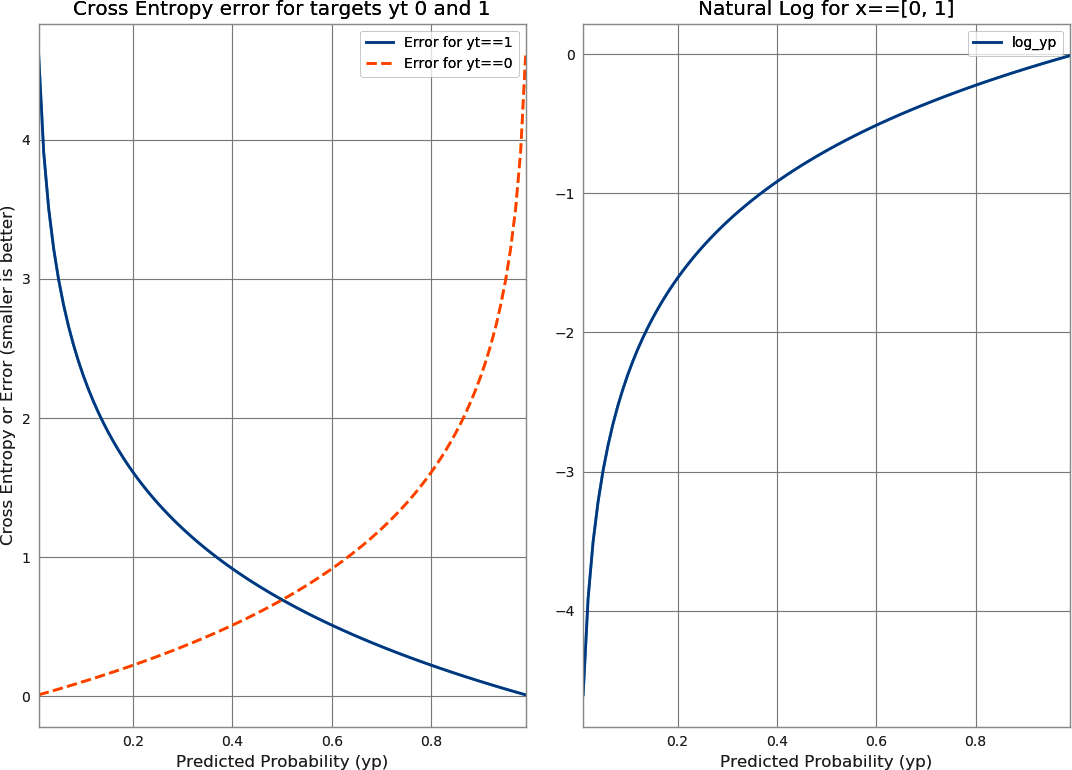

值为0和1的$y_t$的交叉熵（“真值”）

在11-7示例中，我们生成2亿个在[0，1]范围内的随机数作为$y_p$。在这个例子中，$y_t$是期望的真值，一个1的数组。在实际应用中，我们会看到机器学习算法生成的$y_p$，而$y_t$将是机器学习研究人员提供的混合0和1的基本真值。

例11-7。具有大NumPy数组的临时变量的隐藏代价

In [1]:
import ipython_memory_usage.ipython_memory_usage as imu; import numpy as np

In [2]:
%ipython_memory_usage_start

'memory profile enabled'

In [2] used 13.0664 MiB RAM in 7.92s, peaked 0.00 MiB above current, total RAM usage 55.45 MiB


In [3]:
nbr_items = 200_000_000

In [3] used 0.0820 MiB RAM in 0.10s, peaked 0.00 MiB above current, total RAM usage 55.53 MiB


In [4]:
yp = np.random.uniform(low=0.0000001, size=nbr_items)

In [4] used 1528.9492 MiB RAM in 3.37s, peaked 0.00 MiB above current, total RAM usage 1584.48 MiB


In [6]:
yt = np.ones(shape=nbr_items)

In [6] used 1528.9023 MiB RAM in 0.69s, peaked 0.00 MiB above current, total RAM usage 3114.05 MiB


In [7]:
answer = -(yt * np.log(yp) + ((1-yt) * (np.log(1-yp))))

In [7] used 1528.9531 MiB RAM in 12.72s, peaked 4552.48 MiB above current, total RAM usage 4643.01 MiB


In [8]:
del answer

In [8] used -1528.8789 MiB RAM in 0.25s, peaked 1528.88 MiB above current, total RAM usage 3114.13 MiB


yp和yt各占用1.5 GB，使RAM的总使用量略高于3.1 GB。答案向量的维数与输入相同，因此又增加了1.5 GB。请注意，在当前RAM使用情况下，计算峰值为4.5 GB，因此虽然我们以4.6 GB的结果结束，但在计算期间分配了超过9 GB的内存。交叉熵计算创建了几个临时变量（特别是1–yt、np.log（1–yp）和它们的乘法）。如果你有一台8GB的机器，你会因为内存耗尽而无法计算这个结果。

在示例中 11-8，我们在numexpr.evaluate中看到了作为字符串放置的相同表达式。它的峰值比当前使用量高出0gb，在这种情况下不需要任何额外的RAM。值得注意的是，它的计算速度也要快得多：在[6]中，前面的直接向量计算需要18秒，而在这里使用NumExpr时，相同的计算需要2.6秒。

NumExpr将长向量分解为较短的、对缓存友好的块，并对每个块进行串行处理，因此以对缓存友好的方式计算结果的局部块。这说明了不需要额外的RAM和提高的速度。

例11-8。NumExpr将矢量化计算分解为缓存效率高的块

In [9]:
import numexpr

In [9] used 0.4258 MiB RAM in 0.14s, peaked 0.00 MiB above current, total RAM usage 3114.55 MiB


In [10]:
answer = numexpr.evaluate("-(yt * log(yp) + ((1-yt) * (log(1-yp))))")

In [10] used 1529.0625 MiB RAM in 1.18s, peaked 0.00 MiB above current, total RAM usage 4643.62 MiB


我们可以在Pandas身上看到类似的好处 11-9. 我们使用与前面示例中相同的项构造数据帧，并使用df.eval调用NumExpr。Pandas机器需要为NumExpr解包数据帧，并且总体上使用了更多的RAM；在幕后，NumExpr仍然以缓存友好的方式计算结果。请注意，这里除了安装Pandas外，还安装了NumExpr。

例11-9。Pandas eval使用NumExpr（如果可用）

In [12]:
import pandas as pd

df = pd.DataFrame({'yp': np.random.uniform(low=0.0000001, size=nbr_items),
       'yt': np.ones(nbr_items)})

In [12] used 3078.4531 MiB RAM in 8.21s, peaked 2876.42 MiB above current, total RAM usage 7722.11 MiB


In [13]:
answer_eval = df.eval("-(yt * log(yp) + ((1-yt) * (log(1-yp))))")

In [13] used 3058.0977 MiB RAM in 3.91s, peaked 3028.46 MiB above current, total RAM usage 10780.21 MiB


把前面的例子和前面的例子对比一下 11-10，其中NumExpr尚未安装。对df.eval的调用返回到Python解释器上，计算出相同的结果，但执行时间为34秒（与之前的5.2秒相比），峰值内存使用量要大得多。您可以测试NumExpr是否与import NumExpr一起安装如果失败，您将需要安装它。

例11-10。注意，没有NumExpr的Pandas给eval调用缓慢而昂贵

In [14]:
df = pd.DataFrame({'yp': np.random.uniform(low=0.0000001, size=nbr_items),
       'yt': np.ones(nbr_items)})

In [14] used 0.0078 MiB RAM in 6.21s, peaked 6008.37 MiB above current, total RAM usage 10780.22 MiB


In [15]:
answer_eval = df.eval("-(yt * log(yp) + ((1-yt) * (log(1-yp))))")

In [15] used 0.0508 MiB RAM in 4.24s, peaked 6035.67 MiB above current, total RAM usage 10780.27 MiB


如果可以使用NumExpr，那么在大型数组上的复杂向量操作将运行得更快。Pandas不会警告您尚未安装NumExpr，因此如果使用eval，建议您将其添加为安装程序的一部分。IPython内存使用工具将帮助您诊断，如果您有大的阵列处理，您的RAM正在使用；这可以帮助您在当前机器的RAM中容纳更多的内存，这样您就不必开始分割数据和引入更大的工程工作。

# 了解集合中使用的RAM

您可能想知道是否可以向Python询问每个对象使用的RAM。Python的sys.getsizeof（obj）调用将告诉我们一些关于对象使用的内存的信息（大多数但不是所有的对象都提供这种信息）。如果你以前没有见过它，请注意它不会给你一个容器的答案！

让我们先看看一些基本类型。Python中的int是任意大小的可变大小的对象，远高于8字节C整数的范围。在python3.7中，当用0初始化时，基本对象需要24字节。当您计数到较大的数字时，会添加更多的字节：

In [17]:
import sys

sys.getsizeof(0)

24

In [17] used 0.0195 MiB RAM in 0.10s, peaked 0.00 MiB above current, total RAM usage 10780.47 MiB


In [18]:
sys.getsizeof(1)

28

In [18] used 0.0000 MiB RAM in 0.12s, peaked 0.00 MiB above current, total RAM usage 10780.47 MiB


In [19]:
sys.getsizeof((2**30)-1)

28

In [19] used 0.0078 MiB RAM in 0.10s, peaked 0.00 MiB above current, total RAM usage 10780.48 MiB


In [20]:
sys.getsizeof((2**30))

32

In [20] used 0.0039 MiB RAM in 0.11s, peaked 0.00 MiB above current, total RAM usage 10780.48 MiB


在幕后，每次您正在计算的数字的大小超过上一个限制时，都会添加4个字节的集合。这只影响内存使用；你看不出外部有什么不同。

我们可以对字节字符串做同样的检查。一个空字节序列需要33个字节，每增加一个字符就增加1个字节：

In [21]:
sys.getsizeof(b"")

33

In [21] used 0.0234 MiB RAM in 0.11s, peaked 0.00 MiB above current, total RAM usage 10780.51 MiB


In [22]:
sys.getsizeof(b"a")

34

In [22] used 0.0039 MiB RAM in 0.10s, peaked 0.00 MiB above current, total RAM usage 10780.51 MiB


In [23]:
sys.getsizeof(b"ab")

35

In [23] used 0.0039 MiB RAM in 0.10s, peaked 0.00 MiB above current, total RAM usage 10780.52 MiB


In [24]:
sys.getsizeof(b"abc")

36

In [24] used 0.0117 MiB RAM in 0.11s, peaked 0.00 MiB above current, total RAM usage 10780.53 MiB


当我们使用列表时，我们会看到不同的行为。getsizeof不计算列表内容的成本，只计算列表本身的成本。一个空列表需要64字节，而在64位笔记本电脑上，列表中的每一项又需要8字节：

In [25]:
# goes up in 8-byte steps rather than the 24+ we might expect!
sys.getsizeof([])

64

In [25] used 0.0039 MiB RAM in 0.10s, peaked 0.00 MiB above current, total RAM usage 10780.53 MiB


In [26]:
sys.getsizeof([1])

72

In [26] used 0.0078 MiB RAM in 0.12s, peaked 0.00 MiB above current, total RAM usage 10780.54 MiB


In [27]:
sys.getsizeof([1, 2])

80

In [27] used 0.0117 MiB RAM in 0.10s, peaked 0.00 MiB above current, total RAM usage 10780.55 MiB


如果我们使用字节字符串，这一点就更加明显了，我们希望看到的成本比getsizeof报告的要大得多：

In [28]:
sys.getsizeof([b""])

72

In [28] used 0.0039 MiB RAM in 0.11s, peaked 0.00 MiB above current, total RAM usage 10780.55 MiB


In [29]:
sys.getsizeof([b"abcdefghijklm"])

72

In [29] used 0.0000 MiB RAM in 0.11s, peaked 0.00 MiB above current, total RAM usage 10780.55 MiB


In [30]:
sys.getsizeof([b"a", b"b"])

80

In [30] used 0.0078 MiB RAM in 0.11s, peaked 0.00 MiB above current, total RAM usage 10780.56 MiB


getsizeof只报告部分开销，而且通常只针对父对象。如前所述，它也不总是实现的，所以它的用处有限。

Pypler中有一个更好的工具。这将遍历容器的层次结构，并对找到的每个对象的大小进行最佳猜测，将大小添加到总数中。请注意，这是相当缓慢的。

除了依赖猜测和假设之外，asizeof还不能计算幕后分配的内存（例如包装C库的模块可能不会报告C库中分配的字节）。最好以此为指导。我们更喜欢使用memit，因为它能让我们准确地计算出机器上的内存使用情况。

我们可以检查它对一个大列表的估计，这里我们将使用1000万个整数：

In [1]:
from pympler.asizeof import asizeof

In [2]:
asizeof([x for x in range(int(1e7))])

401528048

In [8]:
%memit[x for x in range(int(1e7))]

peak memory: 409.25 MiB, increment: 352.75 MiB


我们可以通过使用memit来验证这个估计，看看这个过程是如何发展的。这两个报告都是近似的memit在执行语句时拍摄操作系统报告的RAM使用情况的快照，asizeof询问对象的大小（可能没有正确报告）。我们可以得出结论，一个列表中的1000万个整数需要320到400 MB的RAM。

一般来说，asizeof进程比使用memit慢，但是asizeof在分析小对象时非常有用。memit对于实际应用程序可能更有用，因为进程的实际内存使用情况是测量的，而不是推断的。

# 字节与Unicode

一个（很多！）与Python2.x相比，Python3.x的优点是默认情况下切换到Unicode。以前，我们混合使用单字节字符串和多字节Unicode对象，这可能会在数据导入和导出过程中造成麻烦。在Python3.x中，默认情况下，所有字符串都是Unicode的，如果您想以字节为单位处理，那么将显式地创建一个字节序列。

Unicode对象在Python3.7中比在Python2.x中更有效地使用RAM。在示例中 11-11，我们可以看到一个一亿字符的序列被构建为一个字节集合和一个Unicode对象。通用字符的Unicode变体（这里我们假设utf8是系统的默认编码）的成本是相同的，这些通用字符使用单字节实现。

例11-11。Unicode对象可以像Python3.x中的字节一样便宜

In [5]:
%load_ext memory_profiler

In [6]:
type(b"b")

bytes

In [7]:
%memit b"a" * int(1e8)

peak memory: 114.54 MiB, increment: 58.28 MiB


In [9]:
type("u")

str

In [10]:
%memit "u" * int(1e8)

peak memory: 140.41 MiB, increment: 83.82 MiB


In [11]:
%memit "Σ" * int(1e8)

peak memory: 241.42 MiB, increment: 184.84 MiB


西格玛字符(Σ) 它在utf8中表示为2字节。得益于pep393，我们从python3.3获得了灵活的Unicode表示。它的工作原理是观察字符串中字符的范围，如果可能的话，使用较小的字节数来表示低阶字符。

Unicode对象的UTF-8编码对每个ASCII字符使用1个字节，对不常见的字符使用更多字节。如果你不确定Unicode编码和Unicode对象的区别，那就去看看Net Batchelder的“实用的Unicode，或者，我该如何停止痛苦？”。

# 在RAM中高效地存储大量文本

文本的一个常见问题是它占用了大量的RAM，但是如果我们想测试之前是否见过字符串或者计算它们的频率，那么将它们放在RAM中要比在磁盘上来回分页方便得多。单纯地存储字符串是昂贵的，但是tries和有向无环字图（DAWG）可以用来压缩它们的表示，并且仍然允许快速操作。

这些更高级的算法可以为您节省大量的RAM，这意味着您可能不需要扩展到更多的服务器。对于生产系统来说，节省的成本是巨大的。在本节中，我们将研究如何使用trie将一组成本为1.2GB的字符串压缩到30MB，而性能只有一点变化。

对于这个例子，我们将使用从Wikipedia的部分转储构建的文本集。这个集合包含来自英文维基百科一部分的1100万个独特的令牌，在磁盘上占用120MB。
代币是从他们原来的文章中分离出来的；它们的长度可变，并且包含Unicode字符和数字。它们看起来像这样：

我们将使用这个文本示例来测试构建包含每个唯一单词的一个实例的数据结构的速度，然后看看查询已知单词的速度有多快（我们将使用画家Alfred Zwiebel的不常见的“Zwiebel”）。这让我们可以问，“我们以前见过Zwiebel吗？”令牌查找是一个常见的问题，能够快速地完成它非常重要。

##### 在1100万个分词上尝试这些方法

图11-2显示了1100万个分词文本文件（120MB原始数据），这些文件使用了我们将在本节中讨论的许多容器来存储。x轴显示每个容器的RAM使用情况，y轴跟踪查询时间，每个点的大小与构建结构所花费的时间有关（越大意味着所花费的时间越长）。

如图所示，集合和列表示例使用了大量RAM；列表示例既大又慢！对于这个数据集，Marisa-trie的例子是RAM效率最高的，而DAWG的运行速度是RAM使用率相对较小的两倍。

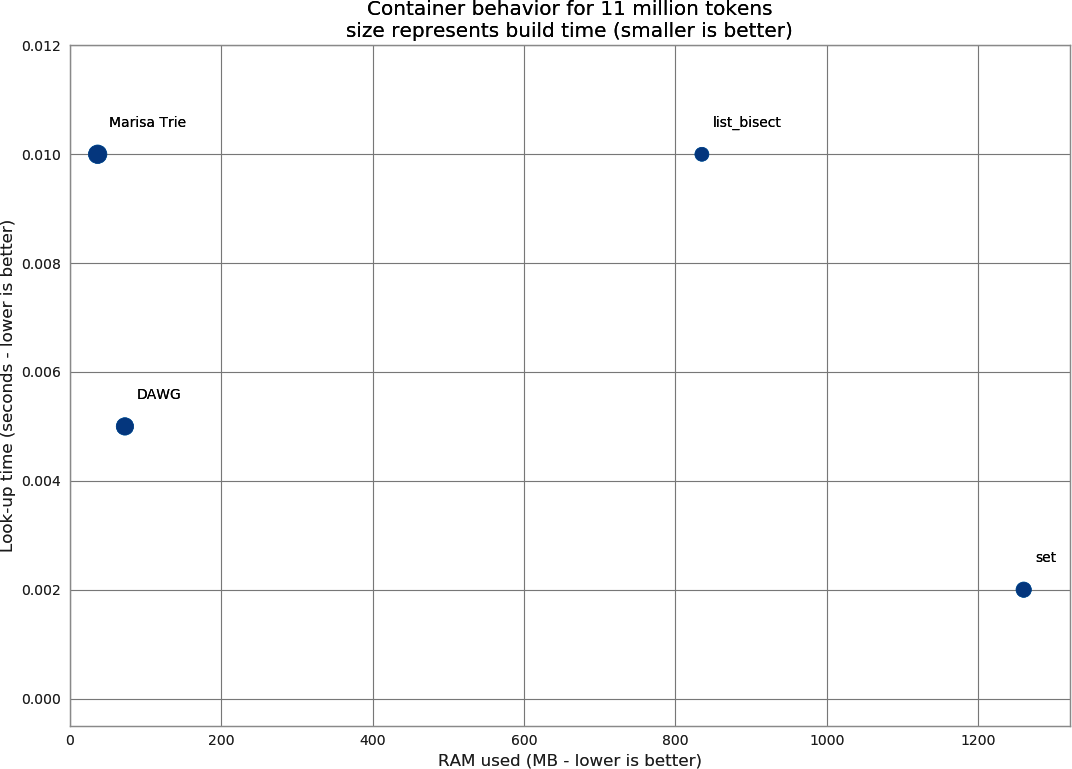

图中没有显示不带排序方法的naivelist的查找时间，我们将很快介绍这种方法，因为它花费的时间太长。请注意，您必须使用各种容器来测试您的问题，每种容器都提供不同的权衡，例如构建时间和API灵活性。

接下来，我们将构建一个流程来测试每个容器的行为。

## LIST

让我们从最简单的方法开始。我们将把令牌加载到一个列表中，然后使用O（n）线性搜索进行查询。您不能在我们已经提到的大型示例上执行此操作搜索花费的时间太长，因此我们将用一个更小（500000令牌）的示例演示此技术。

在下面的每个示例中，我们都使用一个生成器text_example.readers，它一次从输入文件中提取一个Unicode标记。这意味着读取过程仅使用少量RAM：

我们感兴趣的是如何快速查询这个列表。理想情况下，我们希望找到一个容器来存储我们的文本，并允许我们查询和修改它而不受惩罚。要查询它，我们使用timeit多次查找已知单词：

我们的测试脚本报告，大约34 MB用于将原始5 MB文件存储为一个列表，总查找时间为53秒：

将文本存储在未排序的列表中显然是个糟糕的主意；O（n）查找时间和内存使用量都很昂贵。这是世界上最糟糕的！如果我们在下面更大的数据集上尝试此方法，那么我们所讨论的方法的总查找时间应该是25分钟，而不是几分之一秒。

我们可以通过对分模块对列表进行排序并使用二进制搜索来提高查找时间；这为将来的查询提供了一个合理的下限。在示例中 11-12，我们需要计算排序列表所需的时间。在这里，我们切换到更大的1100万令牌集。

例11-12。计时排序操作以准备使用对分

In [ ]:
print("RAM at start {:0.1f}MiB".format(memory_profiler.memory_usage()[0]))
t1 = time.time()
words = [w for w in text_example.readers]
print("Loading {} words".format(len(words)))
t2 = time.time()
print("RAM after creating list {:0.1f}MiB, took {:0.1f}s" \
      .format(memory_profiler.memory_usage()[0], t2 - t1))
print("The list contains {} words".format(len(words)))
words.sort()
t3 = time.time()
print("Sorting list took {:0.1f}s".format(t3 - t2))

接下来，我们执行与前面相同的查找，但添加了使用bisect的index方法：

在示例中 11-13，我们看到RAM的使用量比以前大了很多，因为我们加载了更多的数据。排序还需要0.6秒，累计查找时间为0.01秒。

例11-13。对排序列表使用对分的计时

## SET

使用内置设置似乎是处理任务最明显的方法。在示例中 11-14，集合将每个字符串存储在散列结构中（参见第章） 4如果你需要进修）。检查成员身份很快，但每个字符串必须单独存储，这在RAM上很昂贵。

In [ ]:
words_set = set(text_example.readers)

正如我们在例子中看到的 11-15，该设备使用的RAM比列表多250 MB；然而，它给了我们非常快的查找时间，而不需要额外的索引函数或中间排序操作。

Example 11-15. 运行数据集的例子

如果RAM没有溢价，这可能是最明智的第一种方法。

不过，我们现在已经失去了对原始数据的排序。如果这对您很重要，请注意，您可以将字符串作为键存储在字典中，每个值都是连接到原始读取顺序的索引。通过这种方式，您可以询问字典是否存在键及其索引。

##### 更高效的树结构

让我们介绍一组更有效地使用RAM来表示字符串的算法。

数字 Wikimedia Commons中的11-3显示了trie和DAWG在表示四个单词“tap”、“taps”、“top”和“tops”时的区别。1如果有一个列表或一个集合，这些单词中的每一个都将存储为一个单独的字符串。DAWG和trie都共享部分字符串，因此使用的内存更少。

它们之间的主要区别是trie只共享公共前缀，而DAWG共享公共前缀和后缀。在有许多常用词前缀和后缀的语言（如英语）中，这可以节省大量重复。
准确的内存行为将取决于数据的结构。通常，由于从字符串的开始到结束有多条路径，DAWG无法将值赋给键，但是这里显示的版本可以接受值映射。尝试也可以接受值映射。一些结构必须在一开始就在一个通道中构建，而其他结构可以随时更新。

其中一些结构的一大优点是它们提供了一个公共前缀搜索；也就是说，您可以请求共享您提供的前缀的所有单词。在我们的四个单词的列表中，搜索“ta”的结果将是“tap”和“taps”。此外，由于这些都是通过图形结构发现的，因此检索这些结果的速度非常快。例如，如果您使用的是DNA，那么使用trie压缩数百万个短字符串是减少RAM使用的有效方法。

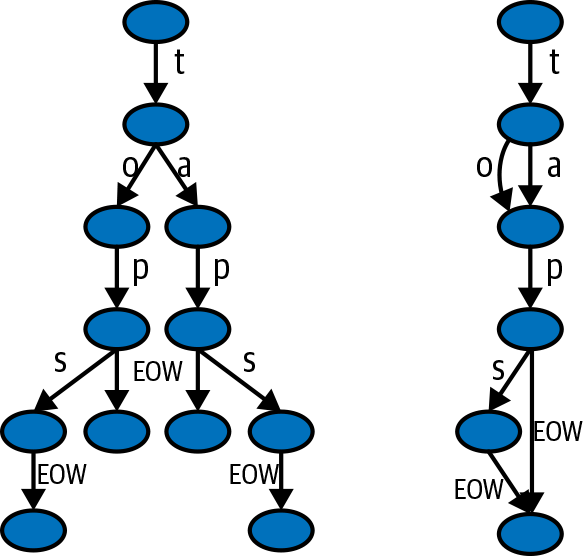

在下面的部分中，我们将更详细地了解DAWGs, tries及其用法。

##### 有向无环图

有向无环字图（MIT许可证）试图有效地表示共享公共前缀和后缀的字符串。

请注意，在编写本文时，必须应用GitHub上的open Pull请求才能使这个DAWG与python3.7一起工作。

在示例中 11-16，你可以看到一个非常简单的设置。对于本实施，施工后不能修改DAWG；它读取一个迭代器来构造自己一次。对于您的用例来说，缺少构建后更新可能会破坏交易。如果是这样，您可能需要考虑改用trie。DAWG确实支持丰富的查询，包括前缀查找；它还允许持久性，并支持将整数索引与字节和记录值一起存储为值。

例11-16。使用DAWG存储数据

正如你在例子中看到的 11-17，对于同一组串，在施工阶段，其使用的RAM明显少于先前的设置示例。更相似的输入文本将导致更强的压缩。

例11-17。运行DAWG示例

更重要的是，如果我们将DAWG持久化到磁盘，如示例所示 11-18，然后将其加载回一个新的Python实例中，我们看到RAM使用量显著减少了磁盘文件和加载后的内存使用量都是70mb；与我们之前构建的1.2GB设置变体相比，这是一个显著的节约！

例11-18。加载在早期会话中构建并保存的DAWG更高效

假设您通常只创建一次DAWG，然后多次加载它，那么在将结构持久化到磁盘之后，您将从重复的构建成本中获益。

## MARISA TRIE

Marisa trie（双许可LGPL和BSD）是一个静态trie，使用Cython绑定到外部库。因为它是静态的，所以在构建之后不能修改。与DAWG一样，它支持将整数索引存储为值，以及字节值和记录值。

键可用于查找值，反之亦然。可以有效地找到共享相同前缀的所有密钥。trie的内容可以持久化。例子 11-19演示了如何使用Marisa trie来存储我们的样本数据。

例11-19。使用Marisa trie存储数据

例11-20。运行Marisa trie示例

trie进一步节省了这个数据集的内存。而在示例中，查找速度稍微慢一点 11-21，在下面的代码片段中，磁盘和RAM的使用量大约为30mb，如果我们将trie保存到磁盘，然后将其加载回一个新的进程中；这是道格成就的两倍。

例11-21。加载在早期会话中构建并保存的Trie更高效

对于您的应用程序，需要研究构造后的存储大小和查找时间之间的权衡。您可能会发现，使用其中一个“效果很好”，因此您可能会避免基准测试其他选项，而只是继续进行下一个挑战。在这种情况下，我们建议您首选Marisa trie；它比GitHub上的达格星还要多。

##### 在生产系统中使用TRIES（和DAWG）

trie和DAWG数据结构提供了很好的好处，但是您仍然必须针对您的问题对它们进行基准测试，而不是盲目地采用它们。如果您的字符串中有重叠的序列，您可能会看到RAM的改进。

Tries和dawg不太为人所知，但它们可以在生产系统中提供强大的优势。我们在“Smesh大型社交媒体分析（2014）”中有一个令人印象深刻的成功案例。DabApps（一家位于英国的Python软件公司）的Jamie Matthews还讲述了如何在客户机系统中使用tries来为客户实现更高效、更廉价的部署：

DAWG和tries是功能强大的数据结构，可以帮助您节省RAM和时间，以换取一点额外的准备工作。对于许多开发人员来说，这些数据结构是不熟悉的，所以考虑将这些代码分离成一个模块，该模块与代码的其余部分合理地隔离开来，以简化维护。

# 使用Scikit Learn的FeatureHasher建模更多文本

scikitlearn是Python最著名的机器学习框架，它对基于文本的自然语言处理（NLP）挑战有极好的支持。在这里，我们将把公共帖子从Usenet档案分类为20个预先指定的类别之一；这类似于清理电子邮件收件箱的两类垃圾邮件分类过程。

文本处理的一个困难是被分析的词汇迅速膨胀。英语使用许多名词（如人名、地名、医学标签和宗教术语）和动词（经常以“-ing”结尾的“做词”，如“跑”、“拿”、“做”和“说”）及其变位（将动词“talk”变成“talked”、“talking”、“talks”），以及其他丰富的语言形式。标点符号和大写给单词的表达增加了额外的细微差别。

对文本进行分类的一种强大而简单的技术是将原始文本分成n个g，通常是unigram、bigram和trigram（也称为1-gram、2-gram和3-gram）。像“有一只猫和一只狗”这样的句子可以变成单字（“有”，“是”，“A”，等等），大字（“有”，“是”，“一只猫”，等等）和三角形（“有”，“是一只猫”，“一只猫和…”）。

这句话有7个单字，6个大字和5个三角形；总的来说，这句话可以用6个独特的单字（因为“a”这个词用了两次）、6个独特的二元结构和5个独特的三元结构来表示，总共有17个描述性项目。如你所见，用来表示一个句子的n-gram词汇迅速增长；有些术语非常常见，有些则非常罕见。

有一些技术可以控制词汇表的爆炸性增长，例如消除停止词（删除最常见且通常不具信息性的术语，如“a”、“the”和“of”）、将所有内容小写以及忽略不太常见的术语类型（如标点符号、数字和方括号）。如果你练习自然语言处理，你很快就会遇到这些方法。

# 介绍DictVectorizer和FeatureHasher

在我们研究Usenet分类任务之前，让我们先看看scikitlearn的两个特性处理工具，它们有助于解决NLP挑战。第一种是DictVectorizer，它获取术语及其频率的字典，并将它们转换为可变宽度的稀疏矩阵（我们将在“SciPy的稀疏矩阵”中讨论稀疏矩阵）。第二个是FeatureHasher，它将相同的术语和频率字典转换为固定宽度的稀疏矩阵。

例子 11-22展示了两个句子——“有一只猫”和“有一只猫和一只狗”，其中一个句子中使用了两个术语“a”。DictVectorizer是在调用中给出句子的fit；在第一个过程中，它将单词列表构建到内部词汇表中，在第二个过程中，它构建一个稀疏矩阵，其中包含对每个术语及其计数的引用。

FeatureHasher的两个过程比一个过程耗时更长，存储词汇表需要额外的RAM。建立词汇表通常是一个连续的过程；通过避免这一阶段，特性散列可能会并行运行以提高速度。

例11-22。基于DictVectorizer的无损文本表示

In [18]:
from sklearn.feature_extraction import DictVectorizer

In [19]:
dv = DictVectorizer()

In [21]:
# frequency counts for ["there is a cat", "there is a cat and a dog"]
token_dict = [{'there': 1, 'is': 1, 'a': 1, 'cat': 1},
              {'there': 1, 'is': 1, 'a': 2, 'cat': 1, 'and': 1,'dog': 1}]

In [22]:
dv.fit(token_dict)

DictVectorizer(dtype=<class 'numpy.float64'>, separator='=', sort=True,
               sparse=True)

In [23]:
print("Vocabulary:")

Vocabulary:


In [25]:
print(dv.vocabulary_)

{'a': 0, 'and': 1, 'cat': 2, 'dog': 3, 'is': 4, 'there': 5}


In [26]:
X = dv.transform(token_dict)

为了使输出更加清晰，请参见图中矩阵X的DataFrame视图 11-4，其中列设置为词汇表。请注意，这里我们对矩阵进行了密集表示，我们有2行6列，12个单元格中的每个单元格都包含一个数字。在稀疏形式中，我们只存储存在的10个计数，而不存储丢失的2个项目的任何内容。对于更大的语料库，密集表示（主要包含0）所需的更大存储空间很快变得令人望而却步。对于NLP，稀疏表示是标准的。

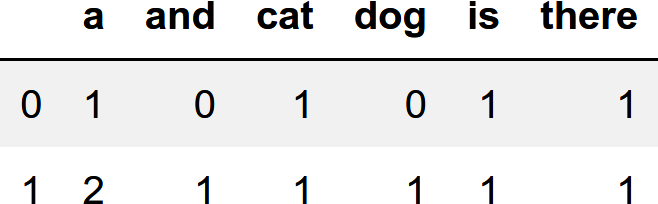

数据帧中显示的DictVectorizer的转换输出

DictVectorizer的一个特点是，我们可以给它一个矩阵并反转过程。在示例中 11-23，我们使用词汇表来恢复原始频率表示。注意，这并不能恢复原来的句子；在第一个例子中，有不止一种解释单词顺序的方法（“有猫”和“有猫”都是有效的解释）。如果我们使用bigrams，我们会开始在单词的顺序上引入一个约束。

例11-23。将矩阵X的输出反转为原始字典表示

In [27]:
print("Reversing the transform:")

Reversing the transform:


In [28]:
print(dv.inverse_transform(X))

[{'a': 1.0, 'cat': 1.0, 'is': 1.0, 'there': 1.0}, {'a': 2.0, 'and': 1.0, 'cat': 1.0, 'dog': 1.0, 'is': 1.0, 'there': 1.0}]


FeatureHasher接受相同的输入并生成类似的输出，但有一个关键区别：它不存储词汇表，而是使用哈希算法为列分配标记频率。

我们已经在“Dictionaries and set是如何工作的”一文中讨论了散列函数。散列将唯一项（在本例中是文本标记）转换为一个数字，其中多个唯一项可能映射到相同的散列值，在这种情况下，我们会遇到冲突。好的散列函数很少引起冲突。如果我们将许多独特的项散列到一个较小的表示中，冲突是不可避免的。散列函数的一个特性是它不容易反转，因此我们不能获取散列值并将其转换回原始标记。

在示例中 11-24，我们要求一个固定宽度的10列矩阵，默认值是100万个元素的固定宽度矩阵，但我们将使用一个小矩阵来显示冲突。对于许多应用程序来说，默认的100万元素宽度是一个合理的默认值。

散列过程使用快速的hash3算法，将每个令牌转换成一个数字；然后将其转换为我们指定的范围。较大的射程几乎没有碰撞；像我们10的小范围会有很多碰撞。由于每个标记都必须映射到10列中的一列，因此如果我们添加大量语句，将会发生许多冲突。

输出X有2行10列；每个标记映射到一列，我们不知道哪个列代表每个单词，因为哈希函数是单向的，所以我们不能将输出映射回输入。在这种情况下，我们可以使用额外的 extra_token_dic 推断出那里的令牌和都映射到第8列，因此我们在第8列中得到9个0和1个2的计数。

例11-24。使用10列FeatureHasher显示哈希冲突

In [29]:
from sklearn.feature_extraction import FeatureHasher

In [31]:
import numpy as np
fh = FeatureHasher(n_features=10, alternate_sign=False)
fh.fit(token_dict)
X = fh.transform(token_dict)
print(X.toarray().astype(np.int_))

[[1 0 0 0 0 0 0 2 0 1]
 [2 0 0 1 0 1 0 2 0 1]]


In [32]:
extra_token_dict = [{'there': 1, 'is': 1}, ]
X = fh.transform(extra_token_dict)
print(X.toarray().astype(np.int_))

[[0 0 0 0 0 0 0 2 0 0]]


尽管发生了冲突，但在这种表示中通常保留了足够多的信号（假设使用了默认的列数），与DictVectorizer相比，FeatureHasher能够获得类似质量的机器学习结果。

# 比较DictVectorizer和FeatureHasher

如果我们使用完整的20个新闻组数据集，我们有20个类别，大约18000封电子邮件分布在各个类别中。虽然有些类别如“sci.med”是相对独特的，但其他类别如“comp.os.ms windows.misc”和“comp.windows.x”将包含具有相似术语的电子邮件。机器学习任务是从测试集中每个项目的20个选项中正确识别正确的新闻组。测试集有大约4000封电子邮件；用于学习术语到匹配类别的映射的训练集大约有14000封电子邮件。

请注意，这个例子并没有处理现实训练挑战的一些必要性。我们还没有剥离新闻组元数据，这些元数据可以用来应对这一挑战；一些无关的元数据并不是仅仅从邮件文本中概括出来的，而是人为地提高了分数。我们把邮件随机地乱排了一下。在这里，我们并不是试图获得一个优秀的机器学习结果；相反，我们演示了有损哈希表示可以等价于无损且更需要内存的变体。

在示例中 11-25，我们获取18846个文档，并使用DictVectorizer和FeatureHasher以及unigrams、bigrams和trigrams构建训练和测试集表示。

DictVectorizer稀疏数组具有训练集的形状（141344335793），其中我们的14134封电子邮件使用400万个令牌表示。建立词汇表和转换训练数据需要42秒。
与FeatureHasher相比，FeatureHasher有一个固定的100万元素范围的散列表示，转换需要21秒。请注意，在这两种情况下，大约980万个非零项存储在稀疏矩阵中，因此它们存储的信息量相似。由于冲突，散列版本存储的项目减少了大约10000个。

如果我们使用密集矩阵，我们将有14000行乘1000万列，使得14000000000个8字节的单元的内存大大超过当前任何机器中通常可用的内存。这个矩阵只有一小部分是非零的。稀疏矩阵避免了这种RAM消耗。

例11-25。比较dictvectorier和FeatureHasher在一个实际机器学习问题上的应用

关键的是，DictVectorizer上使用的LogisticRegression分类器需要花费30%的时间来训练400万列，而FeatureHasher使用的是100万列。两者的得分均为0.89，因此对于这一挑战，结果相当。

使用FeatureHasher，我们在测试集上获得了相同的分数，更快地构建了训练矩阵，避免了构建和存储词汇表，而且我们的训练速度比使用更常见的DictVectorizer方法更快。作为交换，我们已经失去了将散列表示转换回用于调试和解释的原始特性的能力，而且由于我们通常希望能够诊断为什么要做出决策，这对您来说可能太昂贵了。

# SciPy稀疏矩阵

在“介绍DictVectorizer和FeatureHasher”中，我们使用DictVectorizer创建了一个大型特征表示，它在后台使用稀疏矩阵。这些稀疏矩阵也可用于一般计算，在处理稀疏数据时非常有用。

稀疏矩阵是大多数矩阵元素为0的矩阵。对于这些类型的矩阵，有许多方法可以对非零值进行编码，然后简单地说“所有其他值都是零”。除了这些节省内存的方法外，许多算法还具有处理稀疏矩阵的特殊方法，这些方法提供了额外的计算优势：

In [33]:
from scipy import sparse

In [34]:
A_sparse = sparse.random(2048, 2048, 0.05).tocsr()

In [35]:
A_sparse

<2048x2048 sparse matrix of type '<class 'numpy.float64'>'
	with 209715 stored elements in Compressed Sparse Row format>

In [36]:
%timeit A_sparse * A_sparse

10 loops, best of 5: 175 ms per loop


In [37]:
A_dense = A_sparse.todense()

In [38]:
type(A_dense)

<class 'numpy.matrix'>

In [39]:
%timeit A_dense * A_dense

1 loops, best of 5: 175 ms per loop


最简单的实现是针对SciPy中的COO矩阵，对于每个非零元素，除了值的位置之外，我们还存储值。这意味着对于每个非零值，我们总共存储三个数字。只要我们的矩阵至少有66%的零条目，我们就减少了将数据表示为稀疏矩阵所需的内存量，而不是标准的numpy数组。然而，COO矩阵通常仅用于构造稀疏矩阵，而不用于实际计算（因此，CSR/CSC是首选）。

我们可以在图中看到 11-5对于低密度，稀疏矩阵比密集矩阵快得多。除此之外，它们使用的内存也少得多。

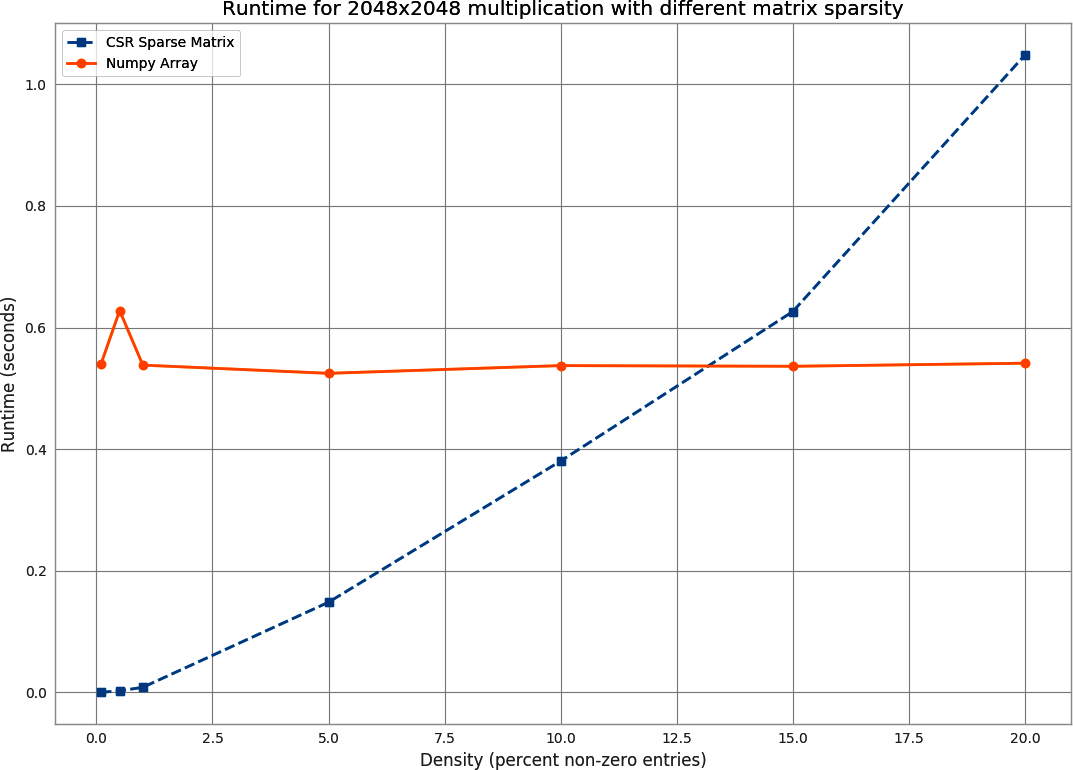

稀疏与密集矩阵乘法

在图中 11-6，密集矩阵始终使用32.7 MB内存（2048 MB）× 2048× 64位）。但是，密度为20%的稀疏矩阵仅使用10MB，节省了70%！随着稀疏矩阵密度的增加，numpy在速度方面迅速占据主导地位，因为它具有矢量化和更好的缓存性能。

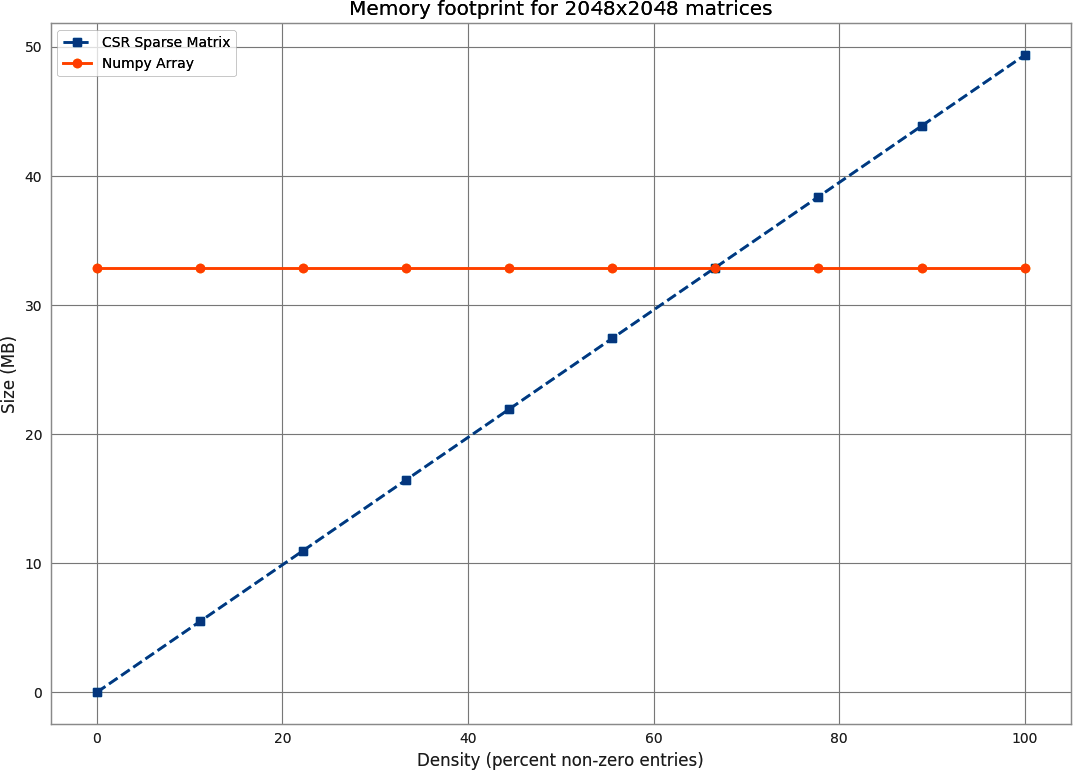

稀疏与密集内存占用

内存使用的极度减少是速度如此之快的部分原因。除了只对非零的元素执行乘法运算（从而减少所需的运算次数），我们也不需要分配如此大的空间来保存结果。这是稀疏数组加速的推拉，它是失去高效缓存和矢量化与不必进行大量与矩阵零值相关的计算之间的平衡。

稀疏矩阵特别擅长的一种运算是余弦相似。事实上，在创建DictVectorizer时，正如我们在“介绍DictVectorizer和FeatureHasher”中所做的那样，通常使用余弦相似性来查看两段文本的相似程度。一般来说，对于这些逐项比较（将一个特定矩阵元素的值与另一个矩阵元素的值进行比较），稀疏矩阵做得很好。由于无论使用普通矩阵还是稀疏矩阵，对numpy的调用都是相同的，因此我们可以在不更改算法代码的情况下对使用稀疏矩阵的好处进行基准测试。

虽然这令人印象深刻，但也存在严重的局限性。稀疏矩阵的支持量非常低，除非运行特殊的稀疏算法或只执行基本操作，否则在支持方面可能会遇到困难。此外，SciPy的稀疏模块提供了稀疏矩阵的多种实现，所有这些实现都有不同的优点和缺点。了解哪一个是最好的使用方法以及何时使用它需要一些专家知识，并且常常导致相互冲突的需求。因此，稀疏矩阵可能不是您经常使用的工具，但是当它们是正确的工具时，它们是非常宝贵的。

# 使用更少内存的技巧

一般来说，如果你能避免把它放进RAM，那么就这样做。你装载的每件东西都要花费你的内存。您可以只加载一部分数据，例如，使用内存映射文件；或者，可以使用生成器只加载部分计算所需的部分数据，而不是一次全部加载。

如果您使用的是数字数据，那么您几乎肯定会希望切换到使用numpy数组—该包提供了许多直接处理底层基本对象的快速算法。与使用数字列表相比，RAM的节省是巨大的，而且时间的节省也是惊人的。此外，如果您处理的是非常稀疏的数组，那么使用SciPy的稀疏数组功能可以节省难以置信的内存量，尽管与普通numpy数组相比，它的特性集减少了。

如果您使用的是字符串，请坚持使用str而不是bytes，除非您有充分的理由在byte级别工作。手工处理大量的文本编码是很痛苦的，UTF-8（或其他Unicode格式）往往会使这些问题消失。如果要在静态结构中存储许多Unicode对象，可能需要研究我们刚才讨论的DAWG和trie结构。

如果您正在处理大量位字符串，请研究numpy和bitarray包；两者都有有效的字节表示。您还可以从Redis中获益，它提供了位模式的高效存储。

PyPy项目正在尝试更有效地表示同构数据结构，因此PyPy中相同基元类型的长列表（例如整数）的成本可能比CPython中的等效结构低得多。任何使用嵌入式系统的人都会对MicroPython项目感兴趣：这个Python的微小内存占用实现旨在实现python3兼容性。

它（几乎！）不用说，你知道当你试图优化RAM使用时，你必须进行基准测试，而且在你进行算法更改之前，有一个单元测试套件是值得的。

在回顾了压缩字符串和有效存储数字的方法之后，我们现在来看看存储空间的交易精度。

# 概率数据结构

概率数据结构允许您在内存使用量大幅减少的情况下，在准确性方面进行权衡。此外，可以对它们执行的操作的数量比使用set或trie限制得多。例如，对于一个使用2.56kb的HyperLogLog++结构，您可以计算最多约7900000000项的唯一项数，错误率为1.625%。

这意味着，如果我们试图计算汽车的唯一车牌号，并且我们的HyperLogLog++计数器显示有654192028个，那么我们有信心实际的车牌号在643561407到664822648之间。此外，如果这种精度不够，您可以简单地向结构中添加更多内存，它的性能会更好。给它40.96kb的资源将把错误从1.625%减少到0.4%。然而，在一个集合中存储这些数据需要3.925 GB，即使假设没有开销！

另一方面，HyperLogLog++结构只能计算一组车牌并与另一组车牌合并。例如，我们可以为每个州设置一个结构，找出每个州有多少个独特的车牌，然后将它们合并，得到整个国家的车牌数。如果给我们一个车牌，我们不能很准确地告诉你我们以前是否见过，也不能给你一个我们已经见过的车牌样本。

当你花时间去理解这个问题，并且需要把一些东西投入生产，这些东西可以回答关于一个非常大的数据集的一个非常小的问题时，概率数据结构是非常棒的。每个结构都有不同的问题，它可以以不同的精度回答，因此找到正确的问题只是理解您的需求的问题。

几乎在所有情况下，概率数据结构都是通过为数据寻找一种更紧凑的替代表示来工作的，它包含了回答某一组问题的相关信息。这可以看作是一种有损压缩，我们可能会丢失某些方面的数据，但我们保留了必要的组件。由于我们允许丢失与我们关心的特定问题不一定相关的数据，这种有损压缩可能比我们以前尝试过的无损压缩更有效。正因为如此，您将使用哪个概率数据结构的选择是非常重要的—您希望选择一个为您的用例保留正确信息的结构！

在我们深入讨论之前，应该弄清楚，这里所有的“错误率”都是用标准差来定义的。这个术语来自于描述高斯分布，并表示函数是如何围绕中心值展开的。当标准差增大时，远离中心点的值的数目也会增大。概率数据结构的错误率是这样定义的，因为它们周围的所有分析都是概率的。例如，当我们说HyperLogLog++算法有一个错误时，我们的意思是68%的时间误差小于err，95%的时间误差小于2× 错误，99.7%的时间它会小于3× 错误

## 用1字节Morris计数器进行非常近似的计数

我们将用最早的概率计数器Morris计数器（由NSA和贝尔实验室的Robert Morris）介绍概率计数的主题。应用包括在受限的RAM环境中（例如，在嵌入式计算机上）计算数以百万计的对象，理解大型数据流，以及处理像图像和语音识别这样的人工智能问题。

Morris计数器跟踪指数并将计数状态建模为（而不是正确的计数）-它提供了一个数量级估计。使用概率规则更新此估计。

我们从指数设为0开始。如果我们问计数器的值，我们会得到pow（2，exponent）=1（敏锐的读者会注意到，这是一个关闭的值，我们说这是一个近似的计数器！）。如果我们要求计数器自身递增，它将生成一个随机数（使用均匀分布），并测试random.uniform（0，1）<=1/pow（2，exponent），它将始终为真（pow（2，0）==1）。计数器递增，指数设置为1。

第二次我们要求计数器自身递增，它将测试random.uniform（0，1）<=1/pow（2，1）。50%的时候都是这样。如果测试通过，则指数递增。如果不是，则不会为此增量请求增加指数。

表 11-1显示了每个第一指数出现增量的可能性。

表11-1。Morris计数详情

<table id="table_morris_counter">
<caption><span class="label">Table 11-1. </span>Morris counter details</caption>
<thead>
<tr>
<th>Exponent</th>
<th>pow(2,<em>exponent</em>)</th>
<th>P(<em>increment</em>)</th>
</tr>
</thead>
<tbody>
<tr>
<td><p>0</p></td>
<td><p>1</p></td>
<td><p>1</p></td>
</tr>
<tr>
<td><p>1</p></td>
<td><p>2</p></td>
<td><p>0.5</p></td>
</tr>
<tr>
<td><p>2</p></td>
<td><p>4</p></td>
<td><p>0.25</p></td>
</tr>
<tr>
<td><p>3</p></td>
<td><p>8</p></td>
<td><p>0.125</p></td>
</tr>
<tr>
<td><p>4</p></td>
<td><p>16</p></td>
<td><p>0.0625</p></td>
</tr>
<tr>
<td><p>…</p></td>
<td><p>…</p></td>
<td><p>…</p></td>
</tr>
<tr>
<td><p>254</p></td>
<td><p>2.894802e+76</p></td>
<td><p>3.454467e-77</p></td>
</tr>
</tbody>
</table>

当我们使用一个无符号字节作为指数时，我们可以近似计算的最大值是math.pow（2255）==5e76。随着计数的增加，相对于实际计数的错误将相当大，但是RAM节省是巨大的，因为我们只使用1字节，而不是我们必须使用的32个无符号字节。例子 11-26展示了Morris计数器的简单实现。

例11-26。简单的Morris计数器实现

In [40]:
"""Approximate Morris counter supporting many counters"""
import math
import random
import array

SMALLEST_UNSIGNED_INTEGER = 'B' # unsigned char, typically 1 byte


class MorrisCounter(object):
    """Approximate counter, stores exponent and counts approximately 2^exponent

    https://en.wikipedia.org/wiki/Approximate_counting_algorithm"""
    def __init__(self, type_code=SMALLEST_UNSIGNED_INTEGER, nbr_counters=1):
        self.exponents = array.array(type_code, [0] * nbr_counters)

    def __len__(self):
        return len(self.exponents)

    def add_counter(self):
        """Add a new zeroed counter"""
        self.exponents.append(0)

    def get(self, counter=0):
        """Calculate approximate value represented by counter"""
        return math.pow(2, self.exponents[counter])

    def add(self, counter=0):
        """Probabilistically add 1 to counter"""
        value = self.get(counter)
        probability = 1.0 / value
        if random.uniform(0, 1) < probability:
            self.exponents[counter] += 1

if __name__ == "__main__":
    mc = MorrisCounter()
    print("MorrisCounter has {} counters".format(len(mc)))
    for n in range(10):
        print("Iteration %d, MorrisCounter has: %d" % (n, mc.get()))
        mc.add()

    for n in range(990):
        mc.add()
    print("Iteration 1000, MorrisCounter has: %d" % (mc.get()))

MorrisCounter has 1 counters
Iteration 0, MorrisCounter has: 1
Iteration 1, MorrisCounter has: 2
Iteration 2, MorrisCounter has: 4
Iteration 3, MorrisCounter has: 8
Iteration 4, MorrisCounter has: 8
Iteration 5, MorrisCounter has: 8
Iteration 6, MorrisCounter has: 8
Iteration 7, MorrisCounter has: 8
Iteration 8, MorrisCounter has: 8
Iteration 9, MorrisCounter has: 8
Iteration 1000, MorrisCounter has: 1024


使用这个实现，我们可以在示例中看到 11-27第一个增加计数器的请求成功，第二个成功，第三个不成功。

例11-27。Morris计数器库示例

In [41]:
mc = MorrisCounter()

In [42]:
mc.get()

1.0

In [43]:
mc.add()

In [44]:
mc.get()

2.0

In [45]:
mc.add()

In [46]:
mc.get()

4.0

In [47]:
mc.add()

In [48]:
mc.get()

4.0

在图中 11-7，粗黑线表示在每次迭代中递增的正整数。在64位计算机上，这是一个8字节的整数。三个1字节Morris计数器的演变如虚线所示；y轴显示它们的值，这些值大致表示每个迭代的真实计数。显示了三个计数器，让您了解它们的不同轨迹和总体趋势；这三个计数器彼此完全独立。

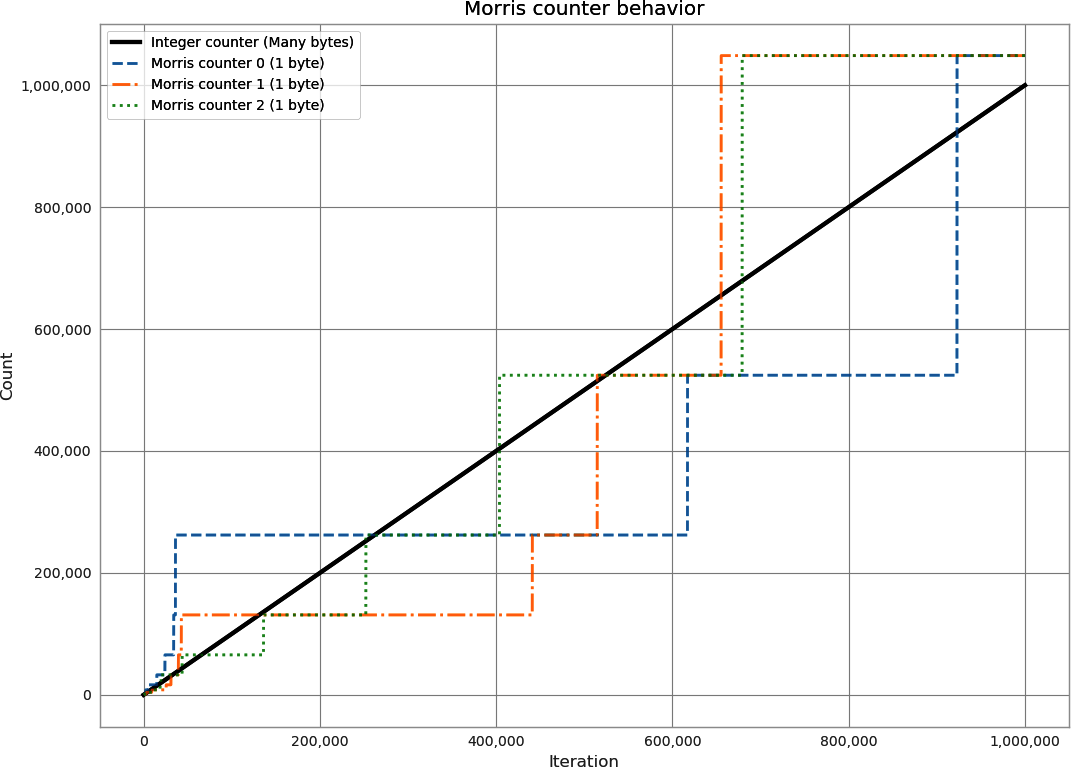

三个1字节Morris计数器与一个8字节整数

此图提供了一些有关使用Morris计数器时预期错误的信息。有关错误行为的更多详细信息，请在线查看。

## K-最小值

在莫里斯柜台，我们丢失了所有关于我们所插入物品的信息。也就是说，无论我们使用.add（“micha”）还是.add（“ian”），计数器的内部状态都是相同的。这些额外的信息是有用的，如果使用得当，可以帮助我们让我们的计数器只计算独特的项目。这样，调用.add（“micha”）数千次只会增加计数器一次。

为了实现这种行为，我们将利用哈希函数的属性（有关哈希函数的更深入讨论，请参阅“哈希函数和熵”）。我们想利用的主要特性是散列函数接受输入并将其均匀分布。例如，假设我们有一个哈希函数，它接收一个字符串并输出一个介于0和1之间的数字。如果该函数是统一的，则意味着当我们将其输入字符串时，我们同样可能得到0.5的值作为0.2的值或任何其他值。这也意味着，如果我们将它输入许多字符串值，我们会期望这些值的间隔相对均匀。记住，这是一个概率论证：值的间隔并不总是均匀的，但是如果我们有很多字符串，并且多次尝试这个实验，它们的间隔往往是均匀的。
假设我们取了100个项目并存储了这些值的散列（散列是从0到1的数字）。知道间距甚至意味着，我们不需要说“我们有100个项目”，我们可以说，“每个项目之间的距离为0.01。”这就是K最小值算法最终在4中出现的地方——如果我们保持我们看到的K最小唯一散列值，我们可以近似计算散列值之间的总间距，并推断出项目的总数。在图中 11-8，随着越来越多的项目被添加，我们可以看到K-最小值结构（也称为KMV）的状态。首先，由于我们没有太多散列值，所以我们保留的最大散列值非常大。随着我们添加的越来越多，我们保存的k散列值中的最大值变得越来越小。利用这种方法，我们可以得到的错误率。

k越大，我们就越能说明我们正在使用的哈希函数对于我们的特定输入和不幸的哈希值不是完全一致的。不幸的散列值的一个例子是散列['A'、'B'、'C']并获得值[0.01、0.02、0.03]。如果我们开始散列越来越多的值，它们聚集的可能性就越来越小。

此外，由于我们只保留最小的唯一散列值，因此数据结构只考虑唯一的输入。我们可以很容易地看到这一点，因为如果我们处于只存储最小的三个哈希值的状态，并且当前[0.1，0.2，0.3]是最小的哈希值，那么如果我们添加哈希值为0.4的内容，我们的状态也不会改变。类似地，如果我们添加更多散列值为0.3的项，我们的状态也不会改变。这是一个称为幂等的性质；这意味着，如果我们用相同的输入对这个结构多次执行相同的操作，状态就不会改变。例如，这与附加在列表上形成对比，附加总是会更改其值。除Morris计数器外，幂等性的概念还适用于本节中的所有数据结构。

例子 11-28显示了一个非常基本的K-最小值实现。值得注意的是我们使用了sortedset，它和set一样，只能包含唯一的项。这种唯一性免费提供了我们的结构幂等性。要了解这一点，请按照代码执行：当同一项被多次添加时，data属性不会更改。

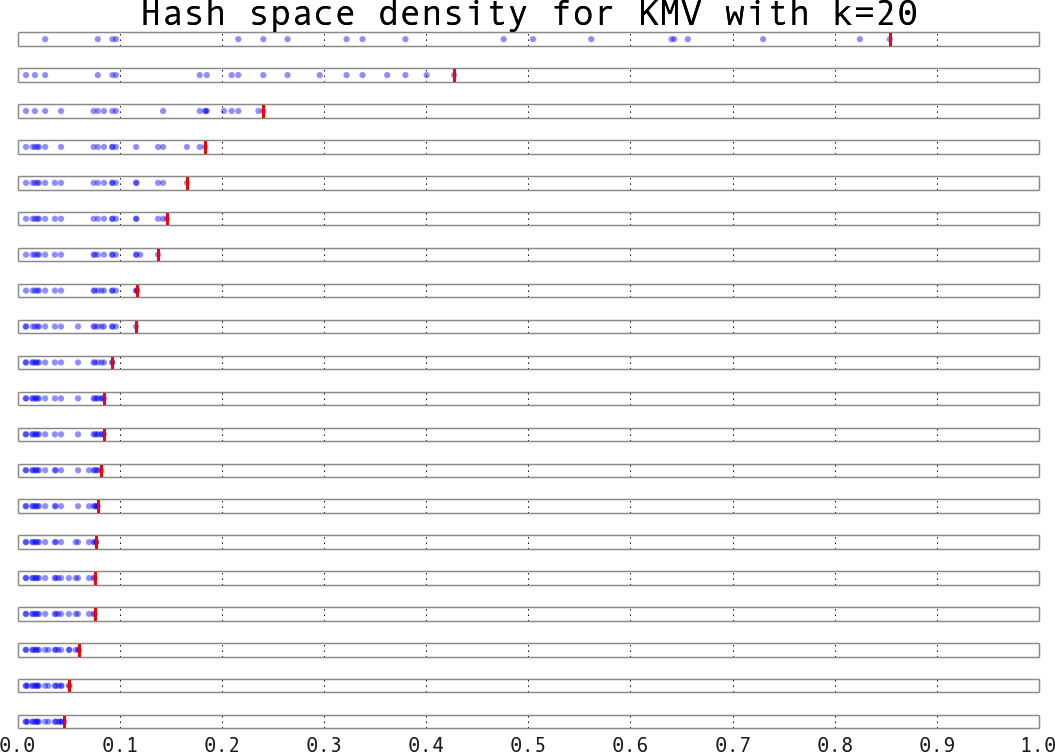

例11-28。简单的KMUES实现

例11-29。countmemaybe KMinValues实现

In [ ]:
kmv1 = KMinValues(k=1024)

In [ ]:
kmv2 = KMinValues(k=1024)

In [ ]:
for i in range(0,50000):  #我们在kmv1中加入了50000个元素。
    kmv1.add(str(i))
   ...:

In [ ]:
for i in range(25000, 75000): #kmv2还获得50000个元素，其中25000个元素也在kmv1中。
    kmv2.add(str(i))
   ...:

In [ ]:
print(len(kmv1))

In [ ]:
print(len(kmv2))

In [ ]:
print(kmv1.cardinality_intersection(kmv2))

In [ ]:
print(kmv1.cardinality_union(kmv2))

注意
在这些算法中，哈希函数的选择对估计的质量有很大的影响。这两个实现都使用mmh3，mmh3是hash3的一个Python实现，对于散列字符串有很好的属性。但是，如果对特定的数据集更方便，可以使用不同的哈希函数。

## Bloom过滤器

有时我们需要能够进行其他类型的集合运算，为此我们需要引入新类型的概率数据结构。Bloom过滤器的诞生是为了回答我们以前是否见过这样一个问题
Bloom过滤器通过具有多个散列值来工作，以便将一个值表示为多个整数。如果我们后来看到某个东西具有相同的整数集，我们可以有理由相信它是相同的值。

为了有效地利用可用资源，我们隐式地将整数编码为列表的索引。这可以看作是一个bool值列表，这些值最初设置为False。如果我们被要求添加一个散列值为[10，4，7]的对象，我们将列表的第十，第四和第七个索引设置为True。将来，如果有人问我们以前是否见过某个项目，我们只需找到它的散列值，然后检查bool列表中所有相应的点是否都设置为True。

这种方法使我们没有假阴性和一个可控的假阳性率。如果布卢姆过滤器说我们以前没有见过一个项目，我们可以100%确定我们以前没有见过这个项目。另一方面，如果bloomfilter声明我们以前见过某个项目，那么很可能我们实际上没有见过，我们只是看到了一个错误的结果。这个错误的结果来自这样一个事实，即我们将有哈希冲突，有时两个对象的哈希值将是相同的，即使对象本身并不相同。然而，在实践中，布卢姆过滤器的错误率被设置为低于0.5%，所以这个错误是可以接受的。

注意
我们可以通过两个彼此独立的散列函数来模拟任意多个散列函数。这种方法称为双重散列。如果我们有一个哈希函数，它给我们两个独立的哈希，我们可以这样做：

模确保得到的哈希值是32位的（对于64位哈希函数，我们将模化2^64-1）。

bool列表的确切长度和每个项目所需的哈希值的数量将根据容量和所需的错误率而固定。通过一些合理简单的统计参数，6我们可以看到理想值如下：

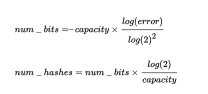

如果我们希望以0.05%的误报率存储50000个对象（不管对象本身有多大）（也就是说，在我们说我们以前见过对象的次数中，有0.05%的时候，我们实际上没有见过），则需要791015位存储和11个哈希函数。

为了进一步提高内存使用效率，我们可以使用单个位来表示bool值（本地bool实际上需要4位）。我们可以通过使用bitarray模块轻松地做到这一点。例子 11-30显示了一个简单的Bloom过滤器实现。

例11-30。简单的Bloom过滤器实现

In [ ]:
import math

import bitarray
import mmh3


class BloomFilter:
    def __init__(self, capacity, error=0.005):
        """
        Initialize a Bloom filter with given capacity and false positive rate
        """
        self.capacity = capacity
        self.error = error
        self.num_bits = int((-capacity * math.log(error)) // math.log(2) ** 2 + 1)
        self.num_hashes = int((self.num_bits * math.log(2)) // capacity + 1)
        self.data = bitarray.bitarray(self.num_bits)

    def _indexes(self, key):
        h1, h2 = mmh3.hash64(key)
        for i in range(self.num_hashes):
            yield (h1 + i * h2) % self.num_bits

    def add(self, key):
        for index in self._indexes(key):
            self.data[index] = True

    def __contains__(self, key):
        return all(self.data[index] for index in self._indexes(key))

    def __len__(self):
        bit_off_num = self.data.count(True)
        bit_off_percent = 1.0 - bit_off_num / self.num_bits
        length = -1.0 * self.num_bits * math.log(bit_off_percent) / self.num_hashes
        return int(length)

    @staticmethod
    def union(bloom_a, bloom_b):
        assert bloom_a.capacity == bloom_b.capacity, "Capacities must be equal"
        assert bloom_a.error == bloom_b.error, "Error rates must be equal"

        bloom_union = BloomFilter(bloom_a.capacity, bloom_a.error)
        bloom_union.data = bloom_a.data | bloom_b.data
        return bloom_union

如果我们插入的项目比我们为Bloom过滤器的容量指定的多，会发生什么情况？在极端情况下，bool列表中的所有项都将设置为True，在这种情况下，我们说我们已经看到了所有项。这意味着Bloom过滤器对其初始容量的设置非常敏感，如果我们处理的是一组大小未知的数据（例如，一个数据流），这可能会非常严重。

处理这种情况的一种方法是使用一种称为可伸缩Bloom过滤器的Bloom过滤器变体。7它们通过将错误率以特定方式变化的多个Bloom过滤器链接在一起来工作。通过这样做，我们可以保证总体错误率，并在需要更多容量时添加新的Bloom过滤器。为了检查我们以前是否看到过一个项目，我们迭代所有的子Blooms，直到找到对象或者耗尽列表。这个结构的一个示例实现可以在示例中看到 11-31，我们使用以前的Bloom过滤器实现底层功能，并且有一个计数器来简化何时添加新Bloom的知道。

例11-31。简单缩放Bloom过滤器实现

In [ ]:
from bloomfilter import BloomFilter

class ScalingBloomFilter:
    def __init__(self, capacity, error=0.005, max_fill=0.8,
                 error_tightening_ratio=0.5):
        self.capacity = capacity
        self.base_error = error
        self.max_fill = max_fill
        self.items_until_scale = int(capacity * max_fill)
        self.error_tightening_ratio = error_tightening_ratio
        self.bloom_filters = []
        self.current_bloom = None
        self._add_bloom()

    def _add_bloom(self):
        new_error = self.base_error * self.error_tightening_ratio ** len(
            self.bloom_filters
        )
        new_bloom = BloomFilter(self.capacity, new_error)
        self.bloom_filters.append(new_bloom)
        self.current_bloom = new_bloom
        return new_bloom

    def add(self, key):
        if key in self:
            return True
        self.current_bloom.add(key)
        self.items_until_scale -= 1
        if self.items_until_scale == 0:
            bloom_size = len(self.current_bloom)
            bloom_max_capacity = int(self.current_bloom.capacity * self.max_fill)

            # We may have been adding many duplicate values into the Bloom, so
            # we need to check if we actually need to scale or if we still have
            # space
            if bloom_size >= bloom_max_capacity:
                self._add_bloom()
                self.items_until_scale = bloom_max_capacity
            else:
                self.items_until_scale = int(bloom_max_capacity - bloom_size)
        return False

    def __contains__(self, key):
        return any(key in bloom for bloom in self.bloom_filters)

    def __len__(self):
        return int(sum(len(bloom) for bloom in self.bloom_filters))

另一种处理方法是使用一种称为定时布鲁姆过滤器的方法。此变体允许元素从数据结构中过期，从而为更多元素释放空间。这对于处理流特别好，因为我们可以让元素在一小时后过期，并将容量设置为足以处理我们每小时看到的数据量。用这种方式使用布卢姆过滤器可以让我们很好地了解过去一个小时发生的事情。

使用这个数据结构就像使用一个set对象。在下面的交互中，我们使用scalable Bloom filter添加几个对象，测试之前是否见过它们，然后尝试通过实验找到假阳性率：

In [ ]:
bloom = BloomFilter(100)

In [ ]:
for i in range(50):
   ....:     bloom.add(str(i))
   ....:

In [ ]:
"20" in bloom

In [ ]:
"25" in bloom

In [ ]:
"51" in bloom

In [ ]:
num_false_positives = 0

In [ ]:
num_true_negatives = 0

In [ ]:
# None of the following numbers should be in the Bloom.

In [ ]:
# If one is found in the Bloom, it is a false positive.

In [ ]:
for i in range(51,10000):
   ....:     if str(i) in bloom:
   ....:         num_false_positives += 1
   ....:     else:
   ....:         num_true_negatives += 1
   ....:

In [ ]:
num_false_positives

In [ ]:
num_true_negatives

In [ ]:
false_positive_rate = num_false_positives / float(10000 - 51)

In [ ]:
false_positive_rate

In [ ]:
bloom.error

我们还可以使用Bloom过滤器进行联合，以连接多个项目集：

bloom_a = BloomFilter(200)

In [ ]:
bloom_b = BloomFilter(200)

In [ ]:
for i in range(50):
   ...:     bloom_a.add(str(i))
   ...:

In [ ]:
for i in range(25,75):
   ...:     bloom_b.add(str(i))
   ...:

In [ ]:
bloom = BloomFilter.union(bloom_a, bloom_b)

In [ ]:
"51" in bloom_a

In [ ]:
"24" in bloom_b

In [ ]:
"25" in bloom

一个警告是，你可以采取联合只有两个开花相同的能力和错误率。此外，最终大方坯的使用容量可以高达两个大方坯联合使用的容量之和。这意味着您可以从两个略超过半满的Bloom过滤器开始，当您将它们结合在一起时，得到一个容量过大且不可靠的新Bloom！

## LogLog Counter

LogLog类型计数器基于这样一种实现：散列函数的各个位也可以被认为是随机的。也就是说，散列的第一位为1的概率为50%，前两位为01的概率为25%，前三位为001的概率为12.5%。知道了这些概率，并将哈希值保持在0的最开头（即，最不可能的哈希值），我们就可以估计出到目前为止我们已经看到了多少项。

这种方法的一个很好的类比就是抛硬币。想象一下，我们想把一枚硬币抛32次，每次都能得到人头。数字32来自这样一个事实：我们使用的是32位哈希函数。如果我们掷硬币一次，它就出现了尾巴，我们将存储数字0，因为我们的最佳尝试产生了0头在一行。既然我们知道掷硬币背后的概率，我们还可以告诉你，我们最长的系列是0长的，你可以估计我们已经尝试了这个实验2^0=1次。如果我们不停地掷硬币，在得到一条尾巴之前，我们能得到10个头像，那么我们就会把数字10储存起来。使用同样的逻辑，你可以估计我们已经尝试了实验2^10=1024次。在这个系统中，我们所能计算的最大翻转次数是我们考虑的最大翻转次数（对于32次翻转，这是2^32=4294967296）。

为了用LogLog类型的计数器对这个逻辑进行编码，我们取输入的哈希值的二进制表示，在看到第一个1之前，先看看有多少个0。散列值可以被认为是一系列的32个硬币翻转，其中0表示正面翻转，1表示反面翻转（即，000010101101表示我们在第一个尾部之前翻转了四个头部，010101101表示我们在翻转第一个尾部之前翻转了一个头部）。这让我们知道在达到这个散列值之前发生了多少次尝试。这个系统背后的数学几乎等同于莫里斯计数器，只有一个主要的例外：我们通过查看实际输入而不是使用随机数生成器来获取“随机”值。这意味着如果我们不断地向LogLog计数器添加相同的值，它的内部状态就不会改变。例子 11-32显示了一个日志计数器的简单实现。

例11-32。LogLog register的简单实现

In [ ]:
import mmh3

def trailing_zeros(number):
    """
    Returns the index of the first bit set to 1 from the right side of a 32-bit
    integer
    >>> trailing_zeros(0)
    32
    >>> trailing_zeros(0b1000)
    3
    >>> trailing_zeros(0b10000000)
    7
    """
    if not number:
        return 32
    index = 0
    while (number >> index) & 1 == 0:
        index += 1
    return index

class LogLogRegister:
    counter = 0
    def add(self, item):
        item_hash = mmh3.hash(str(item))
        return self._add(item_hash)

    def _add(self, item_hash):
        bit_index = trailing_zeros(item_hash)
        if bit_index > self.counter:
            self.counter = bit_index

    def __len__(self):
        return 2**self.counter

这种方法的最大缺点是，我们可能会得到一个哈希值，该值在开始时增加计数器，并使我们的估计发生偏差。这将类似于在第一次尝试时翻转32条尾巴。为了解决这个问题，我们应该让许多人同时掷硬币，并结合他们的结果。大数定律告诉我们，当我们添加越来越多的鳍状肢时，总统计数据受个别鳍状肢异常样本的影响会越来越小。我们组合结果的确切方式是LogLog类型方法（经典LogLog、SuperLogLog、HyperLogLog、HyperLogLog++）之间差异的根源。

我们可以通过获取散列值的前几位并使用它来指定哪个翻转器具有特定的结果来完成这个“多翻转器”方法。如果我们取散列的前4位，这意味着我们有2^4=16个翻转器。由于我们使用了前4位进行选择，所以只剩下28位（对应于每个硬币翻转器的28个单独硬币翻转），这意味着每个计数器最多只能计数2^28=268435456。此外，还有一个常数（alpha）取决于翻转器的数量，它使估计标准化。9所有这些共同为我们提供了一个精确的算法，其中m是使用的寄存器（或翻转器）的数量。例子 11-33展示了LogLog算法的简单实现。

例11-33。LogLog的简单实现

In [ ]:
import mmh3

from llregister import LLRegister

class LL:
    def __init__(self, p):
        self.p = p
        self.num_registers = 2 ** p
        self.registers = [LLRegister() for i in range(int(2 ** p))]
        self.alpha = 0.7213 / (1.0 + 1.079 / self.num_registers)

    def add(self, item):
        item_hash = mmh3.hash(str(item))
        register_index = item_hash & (self.num_registers - 1)
        register_hash = item_hash >> self.p
        self.registers[register_index]._add(register_hash)

    def __len__(self):
        register_sum = sum(h.counter for h in self.registers)
        length = (self.num_registers * self.alpha *
                  2 ** (register_sum / self.num_registers))
        return int(length)

除了此算法通过使用哈希值作为指示符来消除类似项的重复之外，它还有一个可调参数，可用于拨号您愿意做出的任何精度与存储折衷。

在uuu len_uuuu方法中，我们平均所有单个日志寄存器的估计值。然而，这并不是组合数据的最有效方法！这是因为我们可能会得到一些不幸的散列值，使一个特定寄存器的峰值上升，而其他寄存器的值仍然很低。正因为如此，我们能够实现的错误率只有，其中m是使用的寄存器数。

SuperLogLog是为了解决这个问题而设计的。10在这个算法中，只有最低70%的寄存器用于大小估计，它们的值受到限制规则给出的最大值的限制。这个加法将错误率降低到。这是违反直觉的，因为我们通过忽略信息得到了更好的估计！

最后，HyperLogLog在2007年问世，并为我们提供了进一步的精度提升。11它通过改变单个寄存器的平均方法实现了这一点：我们使用了一种球形平均方案，而不仅仅是平均，该方案还特别考虑了结构可能处于的不同边缘情况。这就得出了当前的最佳错误率。此外，此公式删除了SuperLogLog所需的排序操作。当您试图以大容量插入项时，这可以极大地提高数据结构的性能。例子 11-34显示了HyperLogLog的基本实现。

例11-34。HyperLogLog的简单实现

In [ ]:
import math

from ll import LL

class HyperLogLog(LL):
    def __len__(self):
        indicator = sum(2 ** -m.counter for m in self.registers)
        E = self.alpha * (self.num_registers ** 2) / indicator

        if E <= 5.0 / 2.0 * self.num_registers:
            V = sum(1 for m in self.registers if m.counter == 0)
            if V != 0:
                Estar = (self.num_registers *
                         math.log(self.num_registers / (1.0 * V), 2))

            else:
                Estar = E
        else:
            if E <= 2 ** 32 / 30.0:
                Estar = E
            else:
                Estar = -2 ** 32 * math.log(1 - E / 2 ** 32, 2)
        return int(Estar)

if __name__ == "__main__":
    import mmh3

    hll = HyperLogLog(8)
    for i in range(100000):
        hll.add(mmh3.hash(str(i)))
    print(len(hll))

## 现实世界的例子

为了更好地理解数据结构，我们首先创建一个具有许多唯一键的数据集，然后创建一个具有重复项的数据集。图11-9和11-10显示了当我们将这些键输入到我们刚刚查看的数据结构中并定期查询“有多少个唯一的条目？”时的结果，我们可以看到包含更多有状态变量的数据结构（如HyperLogLog和KMinValues）做得更好，因为他们更能处理糟糕的统计数据。另一方面，如果出现一个不幸的随机数或散列值，Morris计数器和单个LogLog寄存器可能会很快产生很高的错误率。然而，对于大多数算法，我们知道有状态变量的数量与错误保证直接相关，因此这是有意义的。

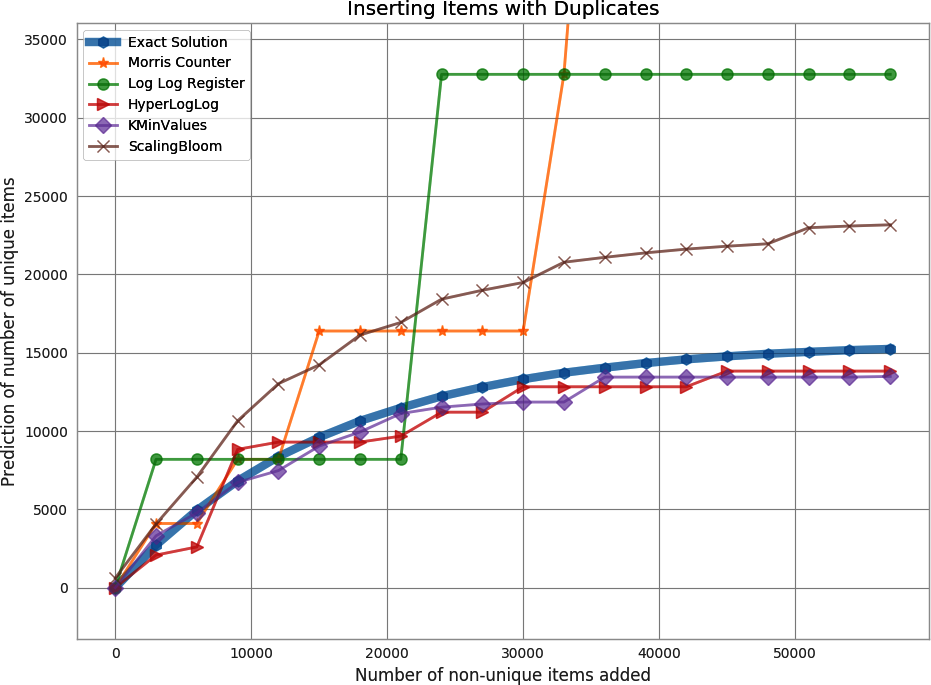

图11-9。使用多个概率数据结构的重复数据的近似计数。为此，我们生成了60000个包含许多重复项的项，并将它们插入到各种概率数据结构中。图表化是对过程中唯一项目数量的结构预测。

看看性能最好的概率数据结构（实际上是您可能会使用的），我们可以总结一下它们的实用性和大致的内存使用情况（见表） 11-2). 根据我们关心的问题，我们可以看到内存使用的巨大变化。这只是强调了一个事实，即在使用概率数据结构时，在继续之前，必须首先考虑关于数据集您真正需要回答的问题。还要注意的是，只有布卢姆过滤器的大小取决于元素的数量。HyperLogLog和KMinValues结构的大小仅取决于错误率。

作为另一个更现实的测试，我们选择使用来自维基百科文本的数据集。我们运行了一个非常简单的脚本，以便从所有文章中提取具有五个或更多字符的所有单字标记，并将它们存储在一个换行分隔的文件中。然后的问题是，“有多少独特的代币？”结果可以在表中看到 11-3.

表11-2。主要概率数据结构及其集合运算的比较

<table id="memory_pd_comparison">
<caption><span class="label">Table 11-2. </span>Comparison of major probabilistic data structures and the set operations available on them</caption>
<thead>
<tr>
<th></th>
<th>Size</th>
<th>Union<sup><a data-type="noteref" id="idm46122397003048-marker" href="ch11.xhtml#idm46122397003048">a</a></sup></th>
<th>Intersection</th>
<th>Contains</th>
<th>Size<sup><a data-type="noteref" id="idm46122397001176-marker" href="ch11.xhtml#idm46122397001176">b</a></sup></th>
</tr>
</thead>
<tbody>
<tr>
<td><p>HyperLogLog</p></td>
<td><p>Yes (<span class="MathJax_Preview"></span><span class="MathJax_SVG" id="MathJax-Element-12-Frame" role="textbox" aria-readonly="true" style="display: inline-block;"><svg xmlns:xlink="http://www.w3.org/1999/xlink" viewBox="0 -1819.09177 4952.3629120000005 3138.18354" style="width: 11.502ex; height: 7.289ex; vertical-align: -3.096ex; margin: 1px 0px;"><g stroke="black" fill="black" stroke-thickness="0" transform="matrix(1 0 0 -1 0 0)"><use xlink:href="#MJMATHI-4F"></use><g transform="translate(768,1819)"><use xlink:href="#MJSZ4-239B" x="0" y="-1165"></use><use xlink:href="#MJSZ4-239D" x="0" y="-2485"></use></g><g transform="translate(1768,0)"><rect stroke="none" width="2184" height="60" x="0" y="220"></rect><g transform="translate(60,615)"><use transform="scale(1.148144)" xlink:href="#MJMAIN-31"></use><use transform="scale(1.148144)" xlink:href="#MJMAIN-2E" x="505" y="0"></use><g transform="translate(904,0)"><use transform="scale(1.148144)" xlink:href="#MJMAIN-30"></use><use transform="scale(1.148144)" xlink:href="#MJMAIN-34" x="505" y="0"></use></g></g><g transform="translate(104,-943)"><use transform="scale(1.148144)" xlink:href="#MJMAIN-221A" x="0" y="-118"></use><rect stroke="none" width="1013" height="68" x="962" y="725"></rect><use transform="scale(1.148144)" xlink:href="#MJMATHI-6D" x="838" y="0"></use></g></g><g transform="translate(4072,1819)"><use xlink:href="#MJSZ4-239E" x="0" y="-1164"></use><use xlink:href="#MJSZ4-23A0" x="0" y="-2485"></use></g></g></svg></span><script type="math/mml" id="MathJax-Element-12"><math xmlns="http://www.w3.org/1998/Math/MathML" alttext="upper O left-parenthesis StartFraction 1.04 Over StartRoot m EndRoot EndFraction right-parenthesis">
  <mrow>
    <mi>O</mi>
    <mo>(</mo>
    <mfrac><mrow><mn>1</mn><mo>.</mo><mn>04</mn></mrow> <msqrt><mi>m</mi></msqrt></mfrac>
    <mo>)</mo>
  </mrow>
</math></script>)</p></td>
<td><p>Yes</p></td>
<td><p>No<sup><a data-type="noteref" id="memory_caveat-marker" href="ch11.xhtml#memory_caveat">c</a></sup></p></td>
<td><p>No</p></td>
<td><p>2.704 MB</p></td>
</tr>
<tr>
<td><p>KMinValues</p></td>
<td><p>Yes (<span class="MathJax_Preview"></span><span class="MathJax_SVG" id="MathJax-Element-13-Frame" role="textbox" aria-readonly="true" style="display: inline-block;"><svg xmlns:xlink="http://www.w3.org/1999/xlink" viewBox="0 -1999.3785480000001 7833.985328000001 3498.7570960000003" style="width: 18.195ex; height: 8.126ex; vertical-align: -3.515ex; margin: 1px 0px;"><g stroke="black" fill="black" stroke-thickness="0" transform="matrix(1 0 0 -1 0 0)"><use xlink:href="#MJMATHI-4F"></use><g transform="translate(768,1999)"><use xlink:href="#MJSZ4-239B" x="0" y="-1165"></use><use xlink:href="#MJSZ4-239D" x="0" y="-2845"></use></g><g transform="translate(1648,0)"><use xlink:href="#MJSZ4-221A" x="0" y="-240"></use><rect stroke="none" width="4300" height="60" x="1005" y="1460"></rect><g transform="translate(1005,0)"><rect stroke="none" width="4180" height="60" x="0" y="220"></rect><use transform="scale(1.148144)" xlink:href="#MJMAIN-32" x="1568" y="514"></use><g transform="translate(60,-952)"><use transform="scale(1.148144)" xlink:href="#MJMATHI-3C0"></use><use transform="scale(1.148144)" xlink:href="#MJMAIN-28" x="578" y="0"></use><use transform="scale(1.148144)" xlink:href="#MJMATHI-6D" x="972" y="0"></use><use transform="scale(1.148144)" xlink:href="#MJMAIN-2212" x="1855" y="0"></use><use transform="scale(1.148144)" xlink:href="#MJMAIN-32" x="2638" y="0"></use><use transform="scale(1.148144)" xlink:href="#MJMAIN-29" x="3143" y="0"></use></g></g></g><g transform="translate(6953,1999)"><use xlink:href="#MJSZ4-239E" x="0" y="-1164"></use><use xlink:href="#MJSZ4-23A0" x="0" y="-2845"></use></g></g></svg></span><script type="math/mml" id="MathJax-Element-13"><math xmlns="http://www.w3.org/1998/Math/MathML" alttext="upper O left-parenthesis StartRoot StartFraction 2 Over pi left-parenthesis m minus 2 right-parenthesis EndFraction EndRoot right-parenthesis">
  <mrow>
    <mi>O</mi>
    <mo>(</mo>
    <msqrt>
      <mfrac><mn>2</mn> <mrow><mi>π</mi><mo>(</mo><mi>m</mi><mo>-</mo><mn>2</mn><mo>)</mo></mrow></mfrac>
    </msqrt>
    <mo>)</mo>
  </mrow>
</math></script>)</p></td>
<td><p>Yes</p></td>
<td><p>Yes</p></td>
<td><p>No</p></td>
<td><p>20.372 MB</p></td>
</tr>
<tr>
<td><p>Bloom filter</p></td>
<td><p>Yes (<span class="MathJax_Preview"></span><span class="MathJax_SVG" id="MathJax-Element-14-Frame" role="textbox" aria-readonly="true" style="display: inline-block;"><svg xmlns:xlink="http://www.w3.org/1999/xlink" viewBox="0 -1819.09177 4952.3629120000005 3138.18354" style="width: 11.502ex; height: 7.289ex; vertical-align: -3.096ex; margin: 1px 0px;"><g stroke="black" fill="black" stroke-thickness="0" transform="matrix(1 0 0 -1 0 0)"><use xlink:href="#MJMATHI-4F"></use><g transform="translate(768,1819)"><use xlink:href="#MJSZ4-239B" x="0" y="-1165"></use><use xlink:href="#MJSZ4-239D" x="0" y="-2485"></use></g><g transform="translate(1768,0)"><rect stroke="none" width="2184" height="60" x="0" y="220"></rect><g transform="translate(60,615)"><use transform="scale(1.148144)" xlink:href="#MJMAIN-30"></use><use transform="scale(1.148144)" xlink:href="#MJMAIN-2E" x="505" y="0"></use><g transform="translate(904,0)"><use transform="scale(1.148144)" xlink:href="#MJMAIN-37"></use><use transform="scale(1.148144)" xlink:href="#MJMAIN-38" x="505" y="0"></use></g></g><g transform="translate(104,-943)"><use transform="scale(1.148144)" xlink:href="#MJMAIN-221A" x="0" y="-118"></use><rect stroke="none" width="1013" height="68" x="962" y="725"></rect><use transform="scale(1.148144)" xlink:href="#MJMATHI-6D" x="838" y="0"></use></g></g><g transform="translate(4072,1819)"><use xlink:href="#MJSZ4-239E" x="0" y="-1164"></use><use xlink:href="#MJSZ4-23A0" x="0" y="-2485"></use></g></g></svg></span><script type="math/mml" id="MathJax-Element-14"><math xmlns="http://www.w3.org/1998/Math/MathML" alttext="upper O left-parenthesis StartFraction 0.78 Over StartRoot m EndRoot EndFraction right-parenthesis">
  <mrow>
    <mi>O</mi>
    <mo>(</mo>
    <mfrac><mrow><mn>0</mn><mo>.</mo><mn>78</mn></mrow> <msqrt><mi>m</mi></msqrt></mfrac>
    <mo>)</mo>
  </mrow>
</math></script>)</p></td>
<td><p>Yes</p></td>
<td><p>No<sup><a data-type="noteref" href="ch11.xhtml#memory_caveat">c</a></sup></p></td>
<td><p>Yes</p></td>
<td><p>197.8 MB</p></td>
</tr>
</tbody>
<tbody><tr class="footnotes"><td colspan="6"><p data-type="footnote" id="idm46122397003048"><sup><a href="ch11.xhtml#idm46122397003048-marker">a</a></sup> Union operations occur without increasing the error rate.</p><p data-type="footnote" id="idm46122397001176"><sup><a href="ch11.xhtml#idm46122397001176-marker">b</a></sup> Size of data structure with 0.05% error rate, 100 million unique elements, and using a 64-bit hashing function.</p><p data-type="footnote" id="memory_caveat"><sup><a href="ch11.xhtml#memory_caveat-marker">c</a></sup> These operations <em>can</em> be done but at a considerable penalty in terms of accuracy.</p></td></tr></tbody></table>

这个实验的主要收获是，如果你能够专门化你的代码，你可以获得惊人的速度和内存增益。整本书都是这样的：当我们将代码专门化为“选择性优化：找到需要修复的内容”时，我们同样能够提高速度。

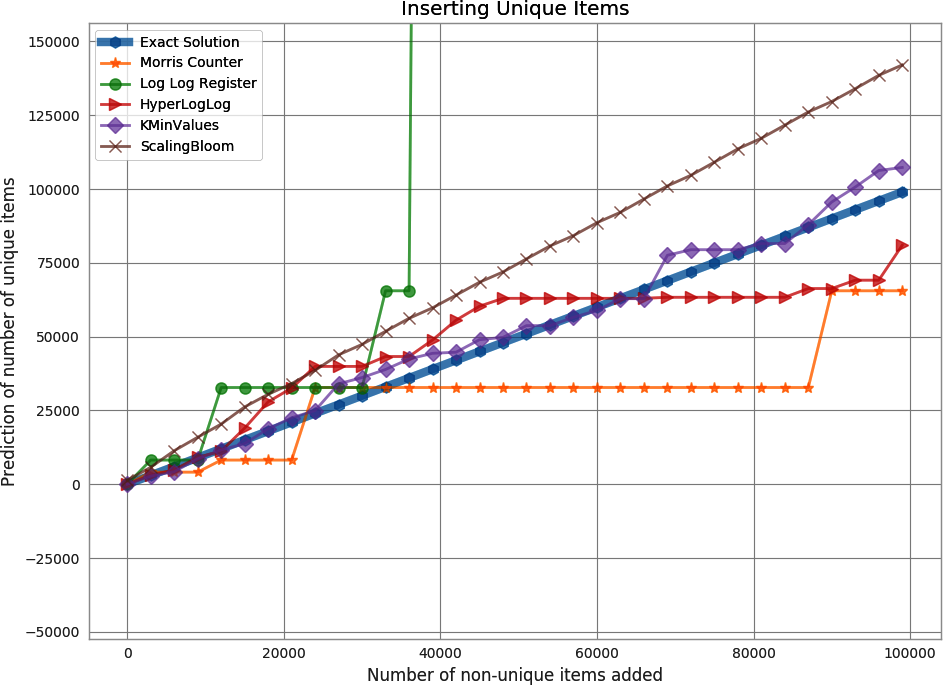

图11-10。使用多个概率数据结构的唯一数据的近似计数。为此，我们将数字1到100000插入到数据结构中。图表化是对过程中唯一项目数量的结构预测。

概率数据结构是一种专门化代码的算法方法。我们只存储所需的数据，以便在给定的误差范围内回答特定的问题。通过只处理给定信息的一个子集，我们不仅可以使内存占用更小，而且可以更快地在结构上执行大多数操作。

<table id="memory_pd_wiki_comparison">
<caption><span class="label">Table 11-3. </span>Size estimates for the number of unique words in Wikipedia</caption>
<thead>
<tr>
<th></th>
<th>Elements</th>
<th>Relative error</th>
<th>Processing time<sup><a data-type="noteref" id="idm46122396962408-marker" href="ch11.xhtml#idm46122396962408">a</a></sup></th>
<th>Structure size<sup><a data-type="noteref" id="idm46122396961256-marker" href="ch11.xhtml#idm46122396961256">b</a></sup></th>
</tr>
</thead>
<tbody>
<tr>
<td><p>Morris counter<sup><a data-type="noteref" id="idm46122396958776-marker" href="ch11.xhtml#idm46122396958776">c</a></sup></p></td>
<td><p>1,073,741,824</p></td>
<td><p>6.52%</p></td>
<td><p>751s</p></td>
<td><p>5 bits</p></td>
</tr>
<tr>
<td><p>LogLog register</p></td>
<td><p>1,048,576</p></td>
<td><p>78.84%</p></td>
<td><p>1,690s</p></td>
<td><p>5 bits</p></td>
</tr>
<tr>
<td><p>LogLog</p></td>
<td><p>4,522,232</p></td>
<td><p>8.76%</p></td>
<td><p>2,112s</p></td>
<td><p>5 bits</p></td>
</tr>
<tr>
<td><p>HyperLogLog</p></td>
<td><p>4,983,171</p></td>
<td><p>–0.54%</p></td>
<td><p>2,907s</p></td>
<td><p>40 KB</p></td>
</tr>
<tr>
<td><p>KMinValues</p></td>
<td><p>4,912,818</p></td>
<td><p>0.88%</p></td>
<td><p>3,503s</p></td>
<td><p>256 KB</p></td>
</tr>
<tr>
<td><p>Scaling Bloom</p></td>
<td><p>4,949,358</p></td>
<td><p>0.14%</p></td>
<td><p>10,392s</p></td>
<td><p>11,509 KB</p></td>
</tr>
<tr>
<td><p>True value</p></td>
<td><p>4,956,262</p></td>
<td><p>0.00%</p></td>
<td><p>-----</p></td>
<td><p>49,558 KB<sup><a data-type="noteref" id="idm46122396935256-marker" href="ch11.xhtml#idm46122396935256">d</a></sup></p></td>
</tr>
</tbody>
<tbody><tr class="footnotes"><td colspan="5"><p data-type="footnote" id="idm46122396962408"><sup><a href="ch11.xhtml#idm46122396962408-marker">a</a></sup> Processing time has been adjusted to remove the time to read the dataset from disk. We also use the simple implementations provided earlier for testing.</p><p data-type="footnote" id="idm46122396961256"><sup><a href="ch11.xhtml#idm46122396961256-marker">b</a></sup> Structure size is theoretical given the amount of data since the implementations used were not optimized.</p><p data-type="footnote" id="idm46122396958776"><sup><a href="ch11.xhtml#idm46122396958776-marker">c</a></sup> Since the Morris counter doesn’t deduplicate input, the size and relative error are given with regard to the total number of values.</p><p data-type="footnote" id="idm46122396935256"><sup><a href="ch11.xhtml#idm46122396935256-marker">d</a></sup> The dataset is 49,558 KB considering only unique tokens, or 8.742 GB with all tokens.</p></td></tr></tbody></table>

因此，无论您是否使用概率数据结构，您都应该始终记住您将要对数据提出哪些问题，以及如何最有效地存储这些数据以提出这些专门问题。这可能归结为使用一种特定类型的列表而不是另一种，使用一种特定类型的数据库索引而不是另一种，甚至可能使用概率数据结构来抛出除相关数据以外的所有数据！